In [4]:
from getpass import getpass
from huggingface_hub import login
login(token=getpass("HF read token: "))

In [11]:
import os
BASE = r"I:/ROBO"
for p in ["data/droid_sample","data/oxe_meta","data/robomind_meta","data/agibot_sample","outputs","codebook"]:
    os.makedirs(os.path.join(BASE,p), exist_ok=True)
print("ok")

ok


In [6]:
import urllib.request
import os  # این خط را اضافه کنید

url = "https://storage.googleapis.com/gresearch/robotics/droid_raw/1.0.1/aggregated-annotations-030724.json"
dst = "I:/ROBO/data/droid_sample/droid_language_annotations.json"
urllib.request.urlretrieve(url, dst)
print("downloaded:", os.path.getsize(dst)//1024, "KB")

downloaded: 11805 KB


 مرحله بعدی: اجرای سلول ۶ (دانلود task_info AgiBot)

In [7]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="agibot-world/AgiBotWorld-Alpha", 
    repo_type="dataset",
    local_dir="I:/ROBO/data/agibot_sample",
    allow_patterns=["task_info/*", "scripts/*", "*.md"]
)
print("✅ task_info AgiBot دانلود شد!")

Fetching 38 files: 100%|██████████| 38/38 [00:04<00:00,  7.92it/s]

✅ task_info AgiBot دانلود شد!


مرحله بعد: اجرای سلول ۸ (محاسبه آنتروپی DROID)

In [8]:
import json
import numpy as np
from collections import Counter

# بارگذاری فایل حاشیه‌نویسی
ann = json.load(open("I:/ROBO/data/droid_sample/droid_language_annotations.json", encoding="utf-8"))

# استخراج افعال
verbs = []
for v in ann.values():
    t = v if isinstance(v, str) else (list(v.values())[0] if isinstance(v, dict) else str(v))
    if t and t.strip():
        verbs.append(t.strip().lower().split()[0])

# محاسبه آنتروپی
c = Counter(verbs)
tot = sum(c.values())
p = np.array([n/tot for n in c.values()])
entropy = float(-(p * np.log(p)).sum())

print(f"✅ DROID verb entropy ≈ {entropy:.3f} nats over {len(c)} verbs")

✅ DROID verb entropy ≈ 2.733 nats over 222 verbs


//////////////////////////////////////////////////////////////////////////////////////////////////////////////
////////////////////////////////////////////////////////////////////////////////////////////////////
///////////////////////////////////////////////////////////////////////////////////////////

سلول یکپارچهٔ ۱ — تشخیص ساختار + آنتروپی استانداردشده (خودکفا)


In [9]:
import json, re, numpy as np
from collections import Counter

ANN_PATH = "I:/ROBO/data/droid_sample/droid_language_annotations.json"
ann = json.load(open(ANN_PATH, encoding="utf-8"))

# (۱) تشخیص ساختار فایل
print("total episodes:", len(ann))
for k in list(ann.keys())[:3]:
    print("KEY:", str(k)[:70], "=>", str(ann[k])[:120])
print("value types:", Counter(type(v).__name__ for v in ann.values()))

# (۲) استخراج همهٔ دستورالعمل‌ها (نه فقط اولی)
def iter_instructions(v):
    if isinstance(v, str):
        if v.strip(): yield v.strip()
    elif isinstance(v, dict):
        for x in v.values():
            if isinstance(x, str) and x.strip(): yield x.strip()
    elif isinstance(v, list):
        for x in v:
            if isinstance(x, str) and x.strip(): yield x.strip()

# (۳) استخراج فعلِ استاندارد: اولین توکن الفبایی، حروف کوچک
def first_verb(s):
    toks = re.findall(r"[a-zA-Z]+", s.lower())
    return toks[0] if toks else None

def entropy_of(strings):
    verbs = [first_verb(s) for s in strings]
    verbs = [x for x in verbs if x]
    c = Counter(verbs); tot = sum(c.values())
    p = np.array([n/tot for n in c.values()])
    return float(-(p*np.log(p)).sum()), len(c), c.most_common(10)

first_only = [next(iter_instructions(v)) for v in ann.values() if list(iter_instructions(v))]
all_instr  = [s for v in ann.values() for s in iter_instructions(v)]

H1, n1, _      = entropy_of(first_only)
H2, n2, top2   = entropy_of(all_instr)
print(f"\n[اولین دستورالعمل]  H={H1:.3f} nats | {n1} فعل یکتا")
print(f"[همهٔ دستورالعمل‌ها] H={H2:.3f} nats | {n2} فعل یکتا")
print("۱۰ فعل پرتکرار:", top2)

total episodes: 50092
KEY: IRIS+7dfa2da3+2023-04-25-11h-42m-28s => {'language_instruction1': 'Pour the contents of the bottle on the right into the sink', 'language_instruction2': 'Pour t
KEY: GuptaLab+553d1bd5+2023-04-20-14h-23m-54s => {'language_instruction1': 'Pick an object from the cup', 'language_instruction2': 'Move the black object on the lid of t
KEY: PennPAL+06b0ffa5+2023-04-29-20h-45m-30s => {'language_instruction1': 'Put the checkered cloth on top of the t-shirt to the left then put it back\n', 'language_inst
value types: Counter({'dict': 50092})

[اولین دستورالعمل]  H=2.733 nats | 217 فعل یکتا
[همهٔ دستورالعمل‌ها] H=2.716 nats | 299 فعل یکتا
۱۰ فعل پرتکرار: [('put', 30559), ('move', 17096), ('pick', 16234), ('remove', 11768), ('take', 6859), ('close', 6311), ('open', 6010), ('place', 4410), ('turn', 3532), ('use', 2868)]


سلول یکپارچهٔ ۲ — دانلود فرادادهٔ باقی‌مانده (RoboMIND + فهرست OXE) در یک بلوک


In [18]:
from huggingface_hub import snapshot_download, HfApi
import pandas as pd, os

# RoboMIND: فقط فراداده (CSV/JSON)، بدون HDF5 سنگین
try:
    snapshot_download(repo_id="x-humanoid-robomind/RoboMIND", repo_type="dataset",
                      local_dir="I:/ROBO/data/robomind_meta",
                      allow_patterns=["*.csv","*.json","*.md","*.txt"])
    print("✅ RoboMIND metadata done")
except Exception as e:
    print("⚠️ RoboMIND:", e, "\n→ اگر 403 بود، در صفحهٔ دیتاست دکمهٔ Agree را بزنید و دوباره اجرا کنید")

# OXE: فقط فهرست ۵۵ زیرمجموعه (بدون دانلود داده)
files = HfApi().list_repo_files("jxu124/OpenX-Embodiment", repo_type="dataset")
subsets = sorted({f.split("/")[0] for f in files if "/" in f})
pd.DataFrame({"oxe_subset": subsets}).to_csv("I:/ROBO/data/oxe_meta/oxe_subsets.csv", index=False)
print(f"✅ {len(subsets)} OXE subsets saved → oxe_subsets.csv")

Fetching 12 files: 100%|██████████| 12/12 [00:02<00:00,  5.33it/s]


✅ RoboMIND metadata done
✅ 55 OXE subsets saved → oxe_subsets.csv


In [1]:
"""
Coverage Debt at Scale - Phase 0/1 pipeline
============================================
Project : Quantifying Long-Tail & Safety-Critical Scenario Representation
          across Cross-Embodiment Robot-Learning Datasets
          (OXE / DROID / RoboMIND / AgiBot)
Target  : IEEE RA-L / T-RO
Env     : Python 3.12, PyTorch-only, Windows (I:/ROBO). No TensorFlow, no gsutil.

SECURITY: never hardcode your HuggingFace token. Use login() interactively,
          or set the environment variable HF_TOKEN before running.

STATUS  : Phase 0 ~done | Phase 1 started (codebook + feature T1).
          Next: resolve RoboMIND gate -> inspect structures -> auto-fill direct
          axes -> pilot-code 5 subsets -> Cohen's kappa.

Run everything:      python coverage_debt_phase01.py
Or import functions:  from coverage_debt_phase01 import droid_verb_entropy, ...
"""

import os
import re
import json
import glob
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd

# ------------------------------- CONFIG -------------------------------
BASE = r"I:/ROBO"
PATHS = {
    "droid_sample":  os.path.join(BASE, "data/droid_sample"),
    "oxe_meta":      os.path.join(BASE, "data/oxe_meta"),
    "robomind_meta": os.path.join(BASE, "data/robomind_meta"),
    "agibot_sample": os.path.join(BASE, "data/agibot_sample"),
    "outputs":       os.path.join(BASE, "outputs"),
    "codebook":      os.path.join(BASE, "codebook"),
}
DROID_ANN_URL  = ("https://storage.googleapis.com/gresearch/robotics/"
                  "droid_raw/1.0.1/aggregated-annotations-030724.json")
DROID_ANN_PATH = os.path.join(PATHS["droid_sample"], "droid_language_annotations.json")


# ------------------------------- STEP 0 -------------------------------
def make_dirs():
    for p in PATHS.values():
        os.makedirs(p, exist_ok=True)
    print("[0] project folders ready")


# ------------------------------- STEP 1 -------------------------------
def hf_login():
    """Login without hardcoding the token.
    (a) set env var HF_TOKEN, or (b) leave it and answer the interactive prompt."""
    from huggingface_hub import login
    tok = os.environ.get("HF_TOKEN")
    login(token=tok) if tok else login()
    print("[1] HuggingFace login ok")


# ------------------------------- STEP 2 -------------------------------
def get_droid_annotations():
    """DROID language annotations (~12 MB) over plain HTTPS. No gsutil / no TF."""
    urllib.request.urlretrieve(DROID_ANN_URL, DROID_ANN_PATH)
    print(f"[2] DROID annotations: {os.path.getsize(DROID_ANN_PATH)//1024} KB")


# --------------------------- STEP 3 (optional) ------------------------
def get_droid_sample():
    """PyTorch-friendly DROID sample (LeRobot parquet+mp4). Only needed when you
    start coding the image-based axes (V*, O*, S*)."""
    from huggingface_hub import snapshot_download
    snapshot_download(repo_id="lerobot/droid_100", repo_type="dataset",
                      local_dir=os.path.join(PATHS["droid_sample"], "droid_100"))
    print("[3] DROID sample (lerobot/droid_100) ok")


# ------------------------------- STEP 4 -------------------------------
def get_robomind_meta():
    """RoboMIND metadata only (CSV/JSON), no heavy HDF5. This repo is GATED."""
    from huggingface_hub import snapshot_download
    try:
        snapshot_download(repo_id="x-humanoid-robomind/RoboMIND", repo_type="dataset",
                          local_dir=PATHS["robomind_meta"],
                          allow_patterns=["*.csv", "*.json", "*.md", "*.txt"])
        print("[4] RoboMIND metadata ok")
    except Exception as e:
        print("[4] RoboMIND FAILED:", type(e).__name__, "-", str(e)[:90])
        print("    This dataset is GATED. Fix:")
        print("      1) re-run hf_login() with your NEW token")
        print("      2) open https://huggingface.co/datasets/x-humanoid-robomind/RoboMIND")
        print("      3) click 'Agree and access repository', then re-run this function")


# ------------------------------- STEP 5 -------------------------------
def get_agibot_taskinfo():
    """AgiBot task_info JSONs only (gated: accept license once on the HF page)."""
    from huggingface_hub import snapshot_download
    snapshot_download(repo_id="agibot-world/AgiBotWorld-Alpha", repo_type="dataset",
                      local_dir=PATHS["agibot_sample"],
                      allow_patterns=["task_info/*", "scripts/*", "*.md"])
    print("[5] AgiBot task_info ok")


# ------------------------------- STEP 6 -------------------------------
def list_oxe_subsets():
    """List the 55 OXE sub-datasets from the public HF mirror (no data download)."""
    from huggingface_hub import HfApi
    files = HfApi().list_repo_files("jxu124/OpenX-Embodiment", repo_type="dataset")
    subsets = sorted({f.split("/")[0] for f in files if "/" in f})
    out = os.path.join(PATHS["oxe_meta"], "oxe_subsets.csv")
    pd.DataFrame({"oxe_subset": subsets}).to_csv(out, index=False)
    print(f"[6] {len(subsets)} OXE subsets -> {out}")
    return subsets


# --------------------------- FEATURE T1: verb entropy ------------------
def _iter_instructions(v):
    """Yield every non-empty instruction string, whatever the container shape."""
    if isinstance(v, str):
        if v.strip():
            yield v.strip()
    elif isinstance(v, dict):
        for x in v.values():
            if isinstance(x, str) and x.strip():
                yield x.strip()
    elif isinstance(v, list):
        for x in v:
            if isinstance(x, str) and x.strip():
                yield x.strip()


def _first_verb(s):
    toks = re.findall(r"[a-zA-Z]+", s.lower())
    return toks[0] if toks else None


def verb_entropy(instructions):
    """Standardized Shannon entropy (nats) over first-verb of each instruction.
    Apply this SAME function to every dataset for a fair comparison."""
    verbs = [_first_verb(s) for s in instructions if s]
    verbs = [x for x in verbs if x]
    c = Counter(verbs)
    tot = sum(c.values())
    p = np.array([n / tot for n in c.values()])
    H = float(-(p * np.log(p)).sum())
    return H, len(c), c.most_common(10)


def _log_metric(record):
    log = os.path.join(PATHS["outputs"], "metrics_log.csv")
    pd.DataFrame([record]).to_csv(log, mode="a",
                                  header=not os.path.exists(log), index=False)


def droid_verb_entropy():
    ann = json.load(open(DROID_ANN_PATH, encoding="utf-8"))
    all_instr = [s for v in ann.values() for s in _iter_instructions(v)]
    H, n, top = verb_entropy(all_instr)
    print(f"[T1] DROID verb entropy = {H:.3f} nats | {n} unique verbs | "
          f"{len(ann)} episodes")
    print("     top verbs:", top)
    _log_metric({"dataset": "DROID", "feature": "T1_verb_entropy",
                 "value": round(H, 4), "n_unique_verbs": n, "n_episodes": len(ann),
                 "method": "all_instructions|regex_first_alpha_token"})
    return H


# ------------------------------ INSPECTORS -----------------------------
def inspect_agibot():
    ti = sorted(glob.glob(os.path.join(PATHS["agibot_sample"], "task_info", "*")))
    print(f"[inspect] AgiBot task_info files: {len(ti)}")
    if ti:
        j = json.load(open(ti[0], encoding="utf-8"))
        rec = j[0] if isinstance(j, list) and j else j
        print("   sample file:", os.path.basename(ti[0]))
        print("   record keys:",
              list(rec.keys()) if isinstance(rec, dict) else type(rec).__name__)
        print("   sample:", json.dumps(rec, ensure_ascii=False)[:600])


def inspect_robomind():
    fs = [f for f in glob.glob(os.path.join(PATHS["robomind_meta"], "**/*"),
                               recursive=True) if os.path.isfile(f)]
    print(f"[inspect] RoboMIND metadata files: {len(fs)}")
    for f in fs[:30]:
        print("  ", os.path.relpath(f, PATHS["robomind_meta"]),
              "-", os.path.getsize(f) // 1024, "KB")


# --------------------------------- MAIN --------------------------------
def main():
    make_dirs()
    hf_login()
    get_droid_annotations()
    # get_droid_sample()      # optional / larger; enable when coding image axes
    get_agibot_taskinfo()
    get_robomind_meta()
    list_oxe_subsets()
    droid_verb_entropy()
    inspect_agibot()
    inspect_robomind()
    print("\nDone. Send me the [inspect] outputs to build the auto-coding parser.")


if __name__ == "__main__":
    main()

[0] project folders ready
[1] HuggingFace login ok


c:\Users\PC369\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2] DROID annotations: 11805 KB


Fetching 38 files: 100%|██████████| 38/38 [00:00<00:00, 325.26it/s]


[5] AgiBot task_info ok


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]


[4] RoboMIND FAILED: GatedRepoError - 401 Client Error. (Request ID: Root=1-6a539272-56aa9fcd64e8845672372ebe;b09fce38-a382-41e1
    This dataset is GATED. Fix:
      1) re-run hf_login() with your NEW token
      2) open https://huggingface.co/datasets/x-humanoid-robomind/RoboMIND
      3) click 'Agree and access repository', then re-run this function
[6] 55 OXE subsets -> I:/ROBO\data/oxe_meta\oxe_subsets.csv
[T1] DROID verb entropy = 2.716 nats | 299 unique verbs | 50092 episodes
     top verbs: [('put', 30559), ('move', 17096), ('pick', 16234), ('remove', 11768), ('take', 6859), ('close', 6311), ('open', 6010), ('place', 4410), ('turn', 3532), ('use', 2868)]
[inspect] AgiBot task_info files: 36
   sample file: task_327.json
   record keys: ['episode_id', 'label_info', 'task_name', 'init_scene_text']
   sample: {"episode_id": 648649, "label_info": {"action_config": [{"start_frame": 8, "end_frame": 218, "action_text": "Retrieve cucumber from the shelf.", "skill": "Pick"}, {"start_fra

In [2]:
"""
Coverage Debt at Scale - Phase 1 coding
=======================================
Adds dataset #2 (AgiBot) to the audit and pre-fills RoboMIND structural axes.

- AgiBot auto-coder: reads data/agibot_sample/task_info/*.json and extracts
  T1 (verb entropy, SAME method as DROID for fair comparison), skill distribution,
  horizon proxies (segments/frames), unique tasks, and init_scene_text (saved for
  later text-based VLM coding of scene/object axes V*/O* - no video needed).
- RoboMIND known metadata: documented, citable structural values from the public
  README/paper (arXiv:2412.13877), so E*/O* axes are filled even while the gated
  file download is pending.

Env: Python 3.12, PyTorch-only, Windows (I:/ROBO).
"""

import os
import re
import json
import glob
from collections import Counter

import numpy as np
import pandas as pd

BASE = r"I:/ROBO"
AGIBOT_TI = os.path.join(BASE, "data/agibot_sample/task_info")
OUT = os.path.join(BASE, "outputs")
os.makedirs(OUT, exist_ok=True)


# ---- shared standardized verb-entropy (identical to the DROID pipeline) ----
def _first_verb(s):
    toks = re.findall(r"[a-zA-Z]+", s.lower())
    return toks[0] if toks else None


def verb_entropy(instructions):
    verbs = [_first_verb(s) for s in instructions if s]
    verbs = [x for x in verbs if x]
    c = Counter(verbs)
    tot = sum(c.values())
    p = np.array([n / tot for n in c.values()])
    return float(-(p * np.log(p)).sum()), len(c), c.most_common(10)


def _log(record):
    log = os.path.join(OUT, "metrics_log.csv")
    pd.DataFrame([record]).to_csv(log, mode="a",
                                  header=not os.path.exists(log), index=False)


# ------------------------------ AgiBot coder ------------------------------
def code_agibot():
    files = sorted(glob.glob(os.path.join(AGIBOT_TI, "*.json")))
    action_texts, skills, task_names, scene_texts = [], [], [], []
    seg_counts, frame_spans, n_episodes = [], [], 0

    for f in files:
        try:
            data = json.load(open(f, encoding="utf-8"))
        except Exception:
            continue
        records = data if isinstance(data, list) else [data]
        for rec in records:
            if not isinstance(rec, dict):
                continue
            n_episodes += 1
            if rec.get("task_name"):
                task_names.append(str(rec["task_name"]))
            if rec.get("init_scene_text"):
                scene_texts.append(str(rec["init_scene_text"]))
            ac = (rec.get("label_info") or {}).get("action_config") or []
            seg_counts.append(len(ac))
            for seg in ac:
                if not isinstance(seg, dict):
                    continue
                if seg.get("action_text"):
                    action_texts.append(seg["action_text"])
                if seg.get("skill"):
                    skills.append(str(seg["skill"]))
                sf, ef = seg.get("start_frame"), seg.get("end_frame")
                if isinstance(sf, (int, float)) and isinstance(ef, (int, float)):
                    frame_spans.append(ef - sf)

    H, nverb, top = verb_entropy(action_texts)
    skill_dist = Counter(skills)
    result = {
        "dataset": "AgiBot(sample)",
        "n_task_files": len(files),
        "n_episodes": n_episodes,
        "n_unique_tasks": len(set(task_names)),
        "n_action_segments": len(action_texts),
        "T1_verb_entropy": round(H, 4),
        "n_unique_verbs": nverb,
        "n_unique_skills": len(skill_dist),
        "median_segments_per_episode": float(np.median(seg_counts)) if seg_counts else None,
        "median_frame_span": float(np.median(frame_spans)) if frame_spans else None,
    }
    print("=== AgiBot (sample) coding ===")
    for k, v in result.items():
        print(f"  {k}: {v}")
    print("  top verbs:", top)
    print("  skill distribution:", skill_dist.most_common())

    _log({"dataset": "AgiBot_sample", "feature": "T1_verb_entropy",
          "value": round(H, 4), "n_unique_verbs": nverb, "n_episodes": n_episodes,
          "method": "all_action_texts|regex_first_alpha_token"})

    # save scene texts for later text-based coding of V*/O* (no video needed)
    if scene_texts:
        pd.DataFrame({"scene_text": scene_texts}).drop_duplicates().to_csv(
            os.path.join(OUT, "agibot_scene_texts.csv"), index=False)
        print(f"  saved {len(set(scene_texts))} unique scene texts -> agibot_scene_texts.csv")
    return result


# --------------- RoboMIND structural axes from public README ---------------
# Source: RoboMIND HF card / paper (arXiv:2412.13877). Citable public values.
ROBOMIND_KNOWN = {
    "total_trajectories": 107000, "n_tasks": 479, "n_object_classes": 96,
    "license": "Apache-2.0",
    "embodiments": {
        "franka_panda_single_arm": 52926,
        "ur5e_single_arm": 25170,
        "tienkung_humanoid": 19152,
        "agilex_dual_arm": 10629,
        # + franka_3rgb (multi-view), franka_fr3_dual, tienkung_xsens, isaac_sim
    },
    "has_simulation_twin": True,
    "has_failure_demos": True,   # ~5k labeled failure demonstrations with causes
}


def show_robomind_known():
    print("\n=== RoboMIND known structural metadata (public, citable) ===")
    print(json.dumps(ROBOMIND_KNOWN, indent=2, ensure_ascii=False))


if __name__ == "__main__":
    code_agibot()
    show_robomind_known()

=== AgiBot (sample) coding ===
  dataset: AgiBot(sample)
  n_task_files: 36
  n_episodes: 34512
  n_unique_tasks: 31
  n_action_segments: 184883
  T1_verb_entropy: 2.7264
  n_unique_verbs: 34
  n_unique_skills: 31
  median_segments_per_episode: 5.0
  median_frame_span: 217.0
  top verbs: [('place', 45649), ('grasp', 28993), ('lift', 21450), ('pick', 11238), ('retrieve', 7940), ('release', 6114), ('press', 5894), ('pass', 5501), ('grab', 4730), ('hang', 4124)]
  skill distribution: [('Pick', 55087), ('Place', 47231), ('Fold', 16466), ('Release', 6114), ('Push', 6023), ('Pour', 5958), ('Grasp', 5725), ('HandOver', 5501), ('Hang', 4124), ('Stretch', 3980), ('Iron', 3980), ('Pull', 2792), ('Drop', 2748), ('Unfold', 2554), ('Scan', 2250), ('Hold', 1844), ('Wipe', 1654), ('Brush', 1510), ('Open', 1504), ('PullApart', 1387), ('PressButton', 1058), ('Close', 1008), ('Shake', 922), ('dip', 844), ('Insert', 808), ('Stack', 739), ('Press', 428), ('Tap', 428), ('Lift', 72), ('Move', 72), ('Lower',

In [12]:
from huggingface_hub import HfApi
try:
    print("logged in as:", HfApi().whoami()["name"])
except Exception as e:
    print("توکن فعلی باطل/بی‌اعتبار است:", type(e).__name__)

توکن فعلی باطل/بی‌اعتبار است: HfHubHTTPError


In [13]:
from huggingface_hub import login
from getpass import getpass
login(token=getpass("توکن جدید HF (Read) را بچسبان (مخفی): "))
print(HfApi().whoami()["name"], "→ ok")

<redacted> → ok


In [14]:
from huggingface_hub import hf_hub_download, HfApi
try:
    p = hf_hub_download(repo_id="x-humanoid-robomind/RoboMIND", repo_type="dataset",
                        filename="RoboMIND_instr.csv", local_dir="I:/ROBO/data/robomind_meta")
    print("✅ downloaded:", p)
except Exception as e:
    print("نام فایل فرق دارد؟ لیست می‌گیریم:", type(e).__name__)
    print([f for f in HfApi().list_repo_files("x-humanoid-robomind/RoboMIND", repo_type="dataset")
           if f.endswith(".csv")][:10])


نام فایل فرق دارد؟ لیست می‌گیریم: RemoteEntryNotFoundError
['static/RoboMIND_v1_2_instr.csv']


In [15]:
import re, json, glob
from collections import Counter
import numpy as np

def _fv(s):
    t = re.findall(r"[a-zA-Z]+", s.lower()); return t[0] if t else None
def tail_stats(counter):
    c = np.array(sorted(counter.values(), reverse=True), dtype=float); p = c/c.sum()
    cum = np.cumsum(np.sort(c)); n = len(c)
    gini = (n + 1 - 2*np.sum(cum)/cum[-1]) / n
    return {"n": n, "top2_mass": round(float(p[:2].sum()),3), "gini": round(float(gini),3)}

ann = json.load(open("I:/ROBO/data/droid_sample/droid_language_annotations.json", encoding="utf-8"))
dv = Counter()
for v in ann.values():
    for s in (v.values() if isinstance(v,dict) else [v]):
        if isinstance(s,str) and s.strip() and _fv(s): dv[_fv(s)] += 1
av, ask = Counter(), Counter()
for f in glob.glob("I:/ROBO/data/agibot_sample/task_info/*.json"):
    for rec in json.load(open(f, encoding="utf-8")):
        for seg in (rec.get("label_info") or {}).get("action_config") or []:
            if seg.get("action_text") and _fv(seg["action_text"]): av[_fv(seg["action_text"])] += 1
            if seg.get("skill"): ask[seg["skill"]] += 1
print("DROID verbs :", tail_stats(dv))
print("AgiBot verbs:", tail_stats(av))
print("AgiBot skills:", tail_stats(ask))

DROID verbs : {'n': 299, 'top2_mass': 0.38, 'gini': 0.956}
AgiBot verbs: {'n': 34, 'top2_mass': 0.404, 'gini': 0.635}
AgiBot skills: {'n': 31, 'top2_mass': 0.553, 'gini': 0.708}


In [16]:
"""
Coverage Debt at Scale - Phase 1 milestone: first four-dataset coverage matrix
==============================================================================
1) Download RoboMIND instructions from the correct path: static/RoboMIND_v1_2_instr.csv
2) Compute RoboMIND T1 (verb entropy) + tail stats using the IDENTICAL method as
   DROID / AgiBot (fair comparison).
3) Assemble coverage_matrix_v1.csv across DROID, AgiBot, RoboMIND, OXE.

Requires: a VALID HF login (huggingface_hub) with access already granted.
Env: Python 3.12, PyTorch-only, Windows (I:/ROBO).
"""

import os
import re
import json
import glob
from collections import Counter

import numpy as np
import pandas as pd
from huggingface_hub import hf_hub_download

BASE = r"I:/ROBO"
OUT = os.path.join(BASE, "outputs")
os.makedirs(OUT, exist_ok=True)


# ------------------------- shared, standardized helpers -------------------------
def _first_verb(s):
    t = re.findall(r"[a-zA-Z]+", s.lower())
    return t[0] if t else None


def verb_counter(texts):
    c = Counter()
    for s in texts:
        if isinstance(s, str) and s.strip():
            v = _first_verb(s)
            if v:
                c[v] += 1
    return c


def stats(counter):
    """Entropy (nats) + breadth + head-mass + Gini for a verb frequency counter."""
    if not counter:
        return {"H": None, "n_verbs": 0, "top2_mass": None, "gini": None}
    vals = np.array(sorted(counter.values(), reverse=True), dtype=float)
    p = vals / vals.sum()
    H = float(-(p * np.log(p)).sum())
    asc = np.sort(vals)
    cum = np.cumsum(asc)
    n = len(vals)
    gini = (n + 1 - 2 * np.sum(cum) / cum[-1]) / n
    return {"H": round(H, 3), "n_verbs": n,
            "top2_mass": round(float(p[:2].sum()), 3),
            "gini": round(float(gini), 3)}


# --------------------------------- DROID ---------------------------------
def code_droid():
    ann = json.load(open(f"{BASE}/data/droid_sample/droid_language_annotations.json",
                         encoding="utf-8"))
    texts = [s for v in ann.values()
             for s in (v.values() if isinstance(v, dict) else [v])
             if isinstance(s, str)]
    return stats(verb_counter(texts))


# --------------------------------- AgiBot --------------------------------
def code_agibot():
    texts = []
    for f in glob.glob(f"{BASE}/data/agibot_sample/task_info/*.json"):
        for rec in json.load(open(f, encoding="utf-8")):
            for seg in (rec.get("label_info") or {}).get("action_config") or []:
                if seg.get("action_text"):
                    texts.append(seg["action_text"])
    return stats(verb_counter(texts))


# -------------------------------- RoboMIND -------------------------------
def code_robomind():
    csv_path = hf_hub_download(
        repo_id="x-humanoid-robomind/RoboMIND", repo_type="dataset",
        filename="static/RoboMIND_v1_2_instr.csv",
        local_dir=f"{BASE}/data/robomind_meta")
    print("RoboMIND instr downloaded ->", csv_path)
    rm = pd.read_csv(csv_path)
    print("RoboMIND columns:", list(rm.columns))
    # auto-detect the instruction/text column
    txtcol = next((c for c in rm.columns
                   if any(k in c.lower() for k in ["instr", "language", "text", "desc"])),
                  rm.columns[-1])
    print("using text column:", txtcol, "| rows:", len(rm))
    return stats(verb_counter(rm[txtcol].dropna().astype(str).tolist()))


# ---------------------------- coverage matrix ----------------------------
def build_matrix():
    droid = code_droid()
    agibot = code_agibot()
    try:
        robomind = code_robomind()
    except Exception as e:
        print("RoboMIND failed:", type(e).__name__, str(e)[:80])
        robomind = {"H": None, "n_verbs": None, "top2_mass": None, "gini": None}

    # structural axes (intra-dataset embodiment diversity, object classes, failure labels)
    # DROID=1 (Franka); AgiBot=1 (G1 humanoid, dual-arm); RoboMIND~5 families; OXE=22
    rows = [
        {"dataset": "DROID",          **droid,    "intra_embodiments": 1,  "object_classes": None, "has_failure_demos": False},
        {"dataset": "AgiBot(sample)", **agibot,   "intra_embodiments": 1,  "object_classes": None, "has_failure_demos": False},
        {"dataset": "RoboMIND",       **robomind, "intra_embodiments": 5,  "object_classes": 96,   "has_failure_demos": True},
        {"dataset": "OXE(55 subsets)","H": None, "n_verbs": None, "top2_mass": None, "gini": None,
                                                  "intra_embodiments": 22, "object_classes": None, "has_failure_demos": None},
    ]
    table = pd.DataFrame(rows)[
        ["dataset", "H", "n_verbs", "top2_mass", "gini",
         "intra_embodiments", "object_classes", "has_failure_demos"]]
    out = os.path.join(OUT, "coverage_matrix_v1.csv")
    table.to_csv(out, index=False)
    print("\n=== First Coverage Matrix (v1) ===")
    print(table.to_string(index=False))
    print("\nsaved ->", out)
    return table


if __name__ == "__main__":
    build_matrix()

RoboMIND instr downloaded -> I:\ROBO\data\robomind_meta\static\RoboMIND_v1_2_instr.csv
RoboMIND columns: ['Unnamed: 0', 'task', 'instruction']
using text column: instruction | rows: 479

=== First Coverage Matrix (v1) ===
        dataset     H  n_verbs  top2_mass  gini  intra_embodiments  object_classes has_failure_demos
          DROID 2.716    299.0      0.380 0.956                  1             NaN             False
 AgiBot(sample) 2.726     34.0      0.404 0.635                  1             NaN             False
       RoboMIND 2.616     50.0      0.509 0.748                  5            96.0              True
OXE(55 subsets)   NaN      NaN        NaN   NaN                 22             NaN              None

saved -> I:/ROBO\outputs\coverage_matrix_v1.csv


###Phase2 risk coverage v0 

In [20]:
"""
Coverage Debt at Scale - Phase 2 (v0): risk-weighted coverage
============================================================
Turns the Phase-1 finding (entropy is invariant, tail structure is not) into the
first risk-aware signal: how much does each dataset UNDER-represent high-risk
actions? This is the embryo of the Coverage Debt (CD) metric and the key
differentiator from entropy-only diversity metrics (e.g. FAKTUAL).

v0 caveats (to be replaced in Phase 3):
  - the risk-tier lexicon is literature-grounded heuristic (irreversibility +
    contact/force intensity), NOT yet empirical.
  - the reference target q_ref is a placeholder; Phase 3 calibrates r(c) and
    q_ref against RoboMIND's ~5k labeled failure demonstrations.

Uses only local files. Env: Python 3.12, PyTorch-only, Windows (I:/ROBO).
"""

import os
import re
import json
import glob
from collections import Counter

import numpy as np
import pandas as pd

BASE = r"I:/ROBO"
OUT = os.path.join(BASE, "outputs")
os.makedirs(OUT, exist_ok=True)

# ---------------------- risk-tier lexicon (transparent v0) ----------------------
# tier 3 = high risk (irreversible / high-contact / tool-use / precision)
# tier 2 = medium (deformable / articulated / directional force)
# tier 1 = low (free-space transport / grasp-release)
RISK = {
    # HIGH (3)
    "insert": 3, "pour": 3, "press": 3, "pressbutton": 3, "stack": 3, "iron": 3,
    "cut": 3, "screw": 3, "plug": 3, "unplug": 3, "hammer": 3, "connect": 3,
    "assemble": 3, "fasten": 3, "squeeze": 3, "pinch": 3, "flip": 3, "dip": 3,
    # MEDIUM (2)
    "open": 2, "close": 2, "push": 2, "pull": 2, "pullapart": 2, "turn": 2,
    "rotate": 2, "fold": 2, "unfold": 2, "hang": 2, "wipe": 2, "brush": 2,
    "shake": 2, "stretch": 2, "scan": 2, "tap": 2, "slide": 2, "wave": 2, "use": 2,
    # LOW (1)
    "pick": 1, "place": 1, "put": 1, "move": 1, "grasp": 1, "grab": 1, "lift": 1,
    "lower": 1, "take": 1, "remove": 1, "release": 1, "drop": 1, "hold": 1,
    "pass": 1, "handover": 1, "retrieve": 1, "reach": 1, "get": 1, "bring": 1,
    "carry": 1, "set": 1,
}
HIGH_STEMS = ("insert", "pour", "press", "stack", "iron", "screw", "plug", "cut")


def tier_of(verb):
    if verb in RISK:
        return RISK[verb]
    for st in HIGH_STEMS:            # catch compounds like 'pressbutton'
        if st in verb:
            return 3
    return None                      # unmapped


# ---------------------- shared verb extraction (same method) ----------------------
def _first_verb(s):
    t = re.findall(r"[a-zA-Z]+", s.lower())
    return t[0] if t else None


def verb_counter(texts):
    c = Counter()
    for s in texts:
        if isinstance(s, str) and s.strip():
            v = _first_verb(s)
            if v:
                c[v] += 1
    return c


def droid_texts():
    ann = json.load(open(f"{BASE}/data/droid_sample/droid_language_annotations.json",
                         encoding="utf-8"))
    return [s for v in ann.values()
            for s in (v.values() if isinstance(v, dict) else [v]) if isinstance(s, str)]


def agibot_texts():
    out = []
    for f in glob.glob(f"{BASE}/data/agibot_sample/task_info/*.json"):
        for rec in json.load(open(f, encoding="utf-8")):
            for seg in (rec.get("label_info") or {}).get("action_config") or []:
                if seg.get("action_text"):
                    out.append(seg["action_text"])
    return out


def robomind_texts():
    p = f"{BASE}/data/robomind_meta/static/RoboMIND_v1_2_instr.csv"
    rm = pd.read_csv(p)
    col = "instruction" if "instruction" in rm.columns else rm.columns[-1]
    return rm[col].dropna().astype(str).tolist()


# ---------------------- risk-weighted coverage per dataset ----------------------
# placeholder reference target over tiers (a "safe generalist" exposure), v0.
Q_REF = {3: 0.15, 2: 0.35, 1: 0.50}
R_W = {3: 3.0, 2: 2.0, 1: 1.0}


def risk_profile(name, texts):
    c = verb_counter(texts)
    total = sum(c.values())
    mass = {1: 0.0, 2: 0.0, 3: 0.0}
    unmapped = 0
    for verb, n in c.items():
        t = tier_of(verb)
        if t is None:
            unmapped += n
        else:
            mass[t] += n
    mapped = total - unmapped
    p = {t: (mass[t] / mapped if mapped else 0.0) for t in (1, 2, 3)}
    # v0 Coverage Debt: risk-weighted under-coverage vs reference target
    cd0 = sum(R_W[t] * max(0.0, Q_REF[t] - p[t]) for t in (2, 3))
    return {
        "dataset": name,
        "p_low": round(p[1], 3), "p_med": round(p[2], 3), "p_high": round(p[3], 3),
        "unmapped_mass": round(unmapped / total, 3) if total else None,
        "CD0_risk_debt": round(cd0, 4),
    }


def main():
    rows = [
        risk_profile("DROID", droid_texts()),
        risk_profile("AgiBot(sample)", agibot_texts()),
        risk_profile("RoboMIND", robomind_texts()),
    ]
    df = pd.DataFrame(rows)
    out = os.path.join(OUT, "risk_coverage_v0.csv")
    df.to_csv(out, index=False)
    print("=== Risk-weighted coverage (v0) ===")
    print(df.to_string(index=False))
    print("\nHigher CD0 = worse (under-represents risky actions relative to q_ref).")
    print("NOTE: q_ref and risk tiers are v0; Phase 3 calibrates them on RoboMIND failures.")
    print("saved ->", out)


if __name__ == "__main__":
    main()

=== Risk-weighted coverage (v0) ===
       dataset  p_low  p_med  p_high  unmapped_mass  CD0_risk_debt
         DROID  0.734  0.223   0.043          0.045         0.5745
AgiBot(sample)  0.802  0.133   0.064          0.089         0.6899
      RoboMIND  0.797  0.165   0.037          0.165         0.7075

Higher CD0 = worse (under-represents risky actions relative to q_ref).
NOTE: q_ref and risk tiers are v0; Phase 3 calibrates them on RoboMIND failures.
saved -> I:/ROBO\outputs\risk_coverage_v0.csv


##Phase2 risk calibration

In [21]:
"""
Coverage Debt at Scale - Phase 2/3 bridge: risk calibration (stage 1)
====================================================================
Goal: make the risk-weighted metric trustworthy, then set up the EMPIRICAL
calibration of r(c) from RoboMIND's real failure data.

This stage (runnable now, local + a repo listing):
  1. report the unmapped verbs per dataset (why RoboMIND was 16.5% unmapped)
  2. expand the risk lexicon and recompute the risk profile (lower unmapped mass)
  3. discover RoboMIND failure-annotation files in the HF repo -> what to download
     next for the real r(c) calibration
  4. calibrate_r_from_failures(): ready scaffold; plug in the failure table later

Env: Python 3.12, PyTorch-only, Windows (I:/ROBO). Needs a valid HF login.
"""

import os
import re
import json
import glob
from collections import Counter

import numpy as np
import pandas as pd

BASE = r"I:/ROBO"
OUT = os.path.join(BASE, "outputs")
os.makedirs(OUT, exist_ok=True)

# ----------------------- expanded risk-tier lexicon (v1) -----------------------
RISK = {
    # HIGH (3): irreversible / high-contact / tool-use / precision
    "insert": 3, "pour": 3, "press": 3, "pressbutton": 3, "stack": 3, "unstack": 3,
    "iron": 3, "cut": 3, "slice": 3, "peel": 3, "screw": 3, "unscrew": 3, "plug": 3,
    "unplug": 3, "hammer": 3, "nail": 3, "drill": 3, "connect": 3, "assemble": 3,
    "fasten": 3, "squeeze": 3, "pinch": 3, "flip": 3, "dip": 3, "scoop": 3, "stir": 3,
    "knead": 3, "crack": 3, "twist": 3, "spread": 3, "fill": 3, "pump": 3,
    # MEDIUM (2): deformable / articulated / directional force / tool-light
    "open": 2, "close": 2, "push": 2, "pull": 2, "pullapart": 2, "turn": 2, "rotate": 2,
    "fold": 2, "unfold": 2, "hang": 2, "unhang": 2, "wipe": 2, "brush": 2, "sweep": 2,
    "mop": 2, "scrub": 2, "shake": 2, "stretch": 2, "scan": 2, "tap": 2, "knock": 2,
    "slide": 2, "wave": 2, "use": 2, "cover": 2, "uncover": 2, "wrap": 2, "unwrap": 2,
    "tie": 2, "untie": 2, "zip": 2, "unzip": 2, "toggle": 2, "switch": 2, "dial": 2,
    "adjust": 2, "align": 2, "straighten": 2, "sort": 2, "arrange": 2, "roll": 2,
    "spray": 2, "apply": 2, "water": 2, "clean": 2, "flatten": 2, "nest": 2,
    # LOW (1): free-space transport / grasp-release / handover
    "pick": 1, "place": 1, "put": 1, "move": 1, "grasp": 1, "grab": 1, "lift": 1,
    "lower": 1, "take": 1, "remove": 1, "release": 1, "drop": 1, "hold": 1, "pass": 1,
    "handover": 1, "retrieve": 1, "reach": 1, "get": 1, "bring": 1, "carry": 1,
    "set": 1, "deliver": 1, "transport": 1, "transfer": 1, "load": 1, "unload": 1,
    "give": 1, "hand": 1, "offer": 1, "present": 1, "position": 1, "orient": 1,
    "throw": 1, "toss": 1, "catch": 1, "empty": 1, "dump": 1, "point": 1,
}
HIGH_STEMS = ("insert", "pour", "press", "stack", "iron", "screw", "plug", "cut",
              "assembl", "fasten", "hammer", "drill")


def tier_of(verb):
    if verb in RISK:
        return RISK[verb]
    for st in HIGH_STEMS:
        if st in verb:
            return 3
    return None


# ----------------------- shared verb extraction -----------------------
def _first_verb(s):
    t = re.findall(r"[a-zA-Z]+", s.lower())
    return t[0] if t else None


def verb_counter(texts):
    c = Counter()
    for s in texts:
        if isinstance(s, str) and s.strip():
            v = _first_verb(s)
            if v:
                c[v] += 1
    return c


def droid_texts():
    ann = json.load(open(f"{BASE}/data/droid_sample/droid_language_annotations.json",
                         encoding="utf-8"))
    return [s for v in ann.values()
            for s in (v.values() if isinstance(v, dict) else [v]) if isinstance(s, str)]


def agibot_texts():
    out = []
    for f in glob.glob(f"{BASE}/data/agibot_sample/task_info/*.json"):
        for rec in json.load(open(f, encoding="utf-8")):
            for seg in (rec.get("label_info") or {}).get("action_config") or []:
                if seg.get("action_text"):
                    out.append(seg["action_text"])
    return out


def robomind_texts():
    rm = pd.read_csv(f"{BASE}/data/robomind_meta/static/RoboMIND_v1_2_instr.csv")
    col = "instruction" if "instruction" in rm.columns else rm.columns[-1]
    return rm[col].dropna().astype(str).tolist()


# ----------------------- (1) report unmapped verbs -----------------------
def report_unmapped(name, texts):
    c = verb_counter(texts)
    total = sum(c.values())
    unmapped = Counter({v: n for v, n in c.items() if tier_of(v) is None})
    um_mass = sum(unmapped.values()) / total if total else 0
    print(f"\n[{name}] unmapped mass = {um_mass:.3f} | top unmapped verbs:")
    print("   ", unmapped.most_common(15))
    return unmapped


# ----------------------- (2) recompute risk profile -----------------------
Q_REF = {3: 0.15, 2: 0.35, 1: 0.50}
R_W = {3: 3.0, 2: 2.0, 1: 1.0}


def risk_profile(name, texts):
    c = verb_counter(texts)
    total = sum(c.values())
    mass = {1: 0.0, 2: 0.0, 3: 0.0}
    unmapped = 0
    for verb, n in c.items():
        t = tier_of(verb)
        if t is None:
            unmapped += n
        else:
            mass[t] += n
    mapped = total - unmapped
    p = {t: (mass[t] / mapped if mapped else 0.0) for t in (1, 2, 3)}
    cd0 = sum(R_W[t] * max(0.0, Q_REF[t] - p[t]) for t in (2, 3))
    return {"dataset": name, "p_low": round(p[1], 3), "p_med": round(p[2], 3),
            "p_high": round(p[3], 3), "unmapped_mass": round(unmapped / total, 3),
            "CD0_risk_debt": round(cd0, 4)}


# ----------------------- (3) discover failure annotations -----------------------
def discover_robomind_failures():
    from huggingface_hub import HfApi
    files = HfApi().list_repo_files("x-humanoid-robomind/RoboMIND", repo_type="dataset")
    hits = [f for f in files if any(k in f.lower()
            for k in ("fail", "annotat", "benchmark", "report", "label", "cause"))]
    print("\n[discover] candidate failure/annotation files in RoboMIND repo:")
    for h in hits[:40]:
        print("   ", h)
    if not hits:
        print("   none matched -> failure labels are likely inside the HDF5 data.")
        print("   see also GitHub: x-humanoid-robomind/RoboMIND-dataset-utils (CSV reports)")
    return hits


# ----------------------- (4) empirical r(c) scaffold -----------------------
def calibrate_r_from_failures(failure_counts: dict, exposure_counts: dict):
    """When we have failure data, set r(verb) proportional to empirical failure rate.
    failure_counts[verb] = #failed demos with that verb
    exposure_counts[verb] = #total demos with that verb
    Returns r(verb) in [1, 3] scaled by relative failure risk."""
    rates = {v: failure_counts.get(v, 0) / exposure_counts[v]
             for v in exposure_counts if exposure_counts[v] > 0}
    if not rates:
        return {}
    lo, hi = min(rates.values()), max(rates.values())
    span = (hi - lo) or 1.0
    return {v: 1.0 + 2.0 * (r - lo) / span for v, r in rates.items()}


def main():
    data = {"DROID": droid_texts(), "AgiBot(sample)": agibot_texts(),
            "RoboMIND": robomind_texts()}

    print("=" * 60, "\n(1) UNMAPPED VERB REPORT (before expansion recheck)")
    for name, txt in data.items():
        report_unmapped(name, txt)

    print("\n" + "=" * 60, "\n(2) RISK PROFILE with expanded lexicon (v1)")
    df = pd.DataFrame([risk_profile(n, t) for n, t in data.items()])
    df.to_csv(os.path.join(OUT, "risk_coverage_v1.csv"), index=False)
    print(df.to_string(index=False))

    print("\n" + "=" * 60)
    discover_robomind_failures()
    print("\nsaved -> risk_coverage_v1.csv")


if __name__ == "__main__":
    main()

(1) UNMAPPED VERB REPORT (before expansion recheck)

[DROID] unmapped mass = 0.019 | top unmapped verbs:
    [('no', 361), ('separate', 155), ('shift', 141), ('slightly', 94), ('draw', 91), ('pile', 79), ('make', 77), ('left', 77), ('lay', 75), ('flick', 53), ('fully', 45), ('unwind', 44), ('attach', 43), ('change', 42), ('first', 42)]

[AgiBot(sample)] unmapped mass = 0.054 | top unmapped verbs:
    [('smooth', 2554), ('grip', 2089), ('clamp', 2089), ('coordinate', 1550), ('swing', 922), ('aim', 750)]

[RoboMIND] unmapped mass = 0.154 | top unmapped verbs:
    [('uncap', 12), ('left', 11), ('the', 5), ('right', 5), ('bread', 3), ('cap', 3), ('mobile', 3), ('puttomato', 2), ('putavocado', 2), ('putplum', 2), ('eggoven', 2), ('upright', 2), ('fetch', 2), ('chili', 2), ('side', 2)]

(2) RISK PROFILE with expanded lexicon (v1)
       dataset  p_low  p_med  p_high  unmapped_mass  CD0_risk_debt
         DROID  0.717  0.237   0.046          0.019         0.5386
AgiBot(sample)  0.804  0.134  

Oxe figure1 

In [1]:
"""
OXE per-subset diversity scatter  ->  paper Figure 1
====================================================
Streams natural-language instructions from OXE subsets (HF mirror
jxu124/OpenX-Embodiment), computes T1 verb-entropy + tail stats per subset,
overlays the three in-hand datasets (DROID / AgiBot / RoboMIND), and saves a
scatter showing: entropy is nearly flat while tail structure (Gini, breadth)
varies enormously -> entropy-only diversity metrics are insufficient.

Requires:  pip install datasets
Note: streaming pulls tar shards on the fly (~0.7-1.5 GB bandwidth per subset,
not permanently stored). Start with a few subsets; edit OXE_LANG_SUBSETS / CAP.
Env: Python 3.12, PyTorch-only, Windows (I:/ROBO).
"""

import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = r"I:/ROBO"
OUT = os.path.join(BASE, "outputs")
os.makedirs(OUT, exist_ok=True)

# OXE subsets that carry language instructions (edit / extend freely)
OXE_LANG_SUBSETS = [
    "taco_play", "jaco_play", "berkeley_autolab_ur5", "viola", "bc_z",
    "austin_buds_dataset_converted_externally_to_rlds",
    # heavier but canonical (uncomment to add): "fractal20220817_data", "bridge",
]
CAP = 120                       # episodes streamed per subset (enough for the distribution)
SKIP_KEYS = ("image", "rgb", "depth", "observation", "pixels", "embedding",
             "flow", "point_cloud", "wrist")


# --------------------------- shared helpers ---------------------------
def _first_verb(s):
    t = re.findall(r"[a-zA-Z]+", s.lower())
    return t[0] if t else None


def stats(counter):
    if not counter:
        return None
    vals = np.array(sorted(counter.values(), reverse=True), dtype=float)
    p = vals / vals.sum()
    H = float(-(p * np.log(p)).sum())
    asc = np.sort(vals); cum = np.cumsum(asc); n = len(vals)
    gini = (n + 1 - 2 * np.sum(cum) / cum[-1]) / n
    return {"H": round(H, 3), "n_verbs": n,
            "top2": round(float(p[:2].sum()), 3), "gini": round(float(gini), 3)}


def find_language(x, depth=0):
    """Recursively yield instruction-like strings; skips image/observation keys."""
    if depth > 6:
        return
    if isinstance(x, bytes):
        try:
            x = x.decode("utf-8", "ignore")
        except Exception:
            return
    if isinstance(x, dict):
        for k, v in x.items():
            kl = str(k).lower()
            if any(sk in kl for sk in SKIP_KEYS):
                continue
            if isinstance(v, (str, bytes)) and any(t in kl for t in
                                                   ("language", "instruction", "natural")):
                s = v.decode("utf-8", "ignore") if isinstance(v, bytes) else v
                if s and s.strip():
                    yield s.strip()
            else:
                yield from find_language(v, depth + 1)
    elif isinstance(x, (list, tuple)):
        for v in x[:60]:
            yield from find_language(v, depth + 1)


def code_subset(name, cap=CAP):
    from datasets import load_dataset
    ds = load_dataset("jxu124/OpenX-Embodiment", name, split="train",
                      streaming=True, trust_remote_code=True)
    c = Counter(); seen = 0
    for ex in ds:
        for instr in find_language(ex):
            v = _first_verb(instr)
            if v:
                c[v] += 1
        seen += 1
        if seen >= cap:
            break
    return c, seen


def probe():
    """Test datasets-library compatibility on ONE subset before the full loop."""
    try:
        import datasets  # noqa
    except ImportError:
        print("نصب کنید:  pip install datasets"); return False
    print("probe: streaming 5 episodes of 'taco_play' ...")
    try:
        c, seen = code_subset("taco_play", cap=5)
        print("  OK ->", stats(c), "| verbs found from", seen, "eps:", c.most_common(5))
        return True
    except Exception as e:
        print("  probe FAILED:", type(e).__name__, "-", str(e)[:120])
        print("  → نسخهٔ datasets شما احتمالاً loading-script را رد می‌کند.")
        print("    همین پیام خطا را بفرست تا نسخهٔ fallback (دانلود مستقیم shard) را بدهم.")
        return False


def main():
    if not probe():
        return
    rows = []
    for name in OXE_LANG_SUBSETS:
        try:
            c, seen = code_subset(name); st = stats(c)
            if st:
                rows.append({"subset": name[:26], "source": "OXE", **st, "episodes": seen})
                print(f"{name[:30]:30s} -> {st}  ({seen} eps)")
            else:
                print(f"{name[:30]:30s} -> no language found, skip")
        except Exception as e:
            print(f"{name[:30]:30s} -> skip ({type(e).__name__})")

    inhand = [
        {"subset": "DROID",    "source": "main", "H": 2.716, "n_verbs": 299, "top2": 0.380, "gini": 0.956, "episodes": 50092},
        {"subset": "AgiBot",   "source": "main", "H": 2.726, "n_verbs": 34,  "top2": 0.404, "gini": 0.635, "episodes": 34512},
        {"subset": "RoboMIND", "source": "main", "H": 2.616, "n_verbs": 50,  "top2": 0.509, "gini": 0.748, "episodes": 479},
    ]
    df = pd.DataFrame(rows + inhand)
    df.to_csv(os.path.join(OUT, "figure1_entropy_vs_tail.csv"), index=False)

    fig, ax = plt.subplots(figsize=(7, 5))
    for src, mk, col in [("OXE", "o", "#4C78A8"), ("main", "*", "#E45756")]:
        sub = df[df.source == src]
        if len(sub):
            ax.scatter(sub.H, sub.gini, s=40 + 4 * np.sqrt(sub.n_verbs),
                       marker=mk, c=col, alpha=0.75, label=src,
                       edgecolor="k", linewidth=0.4)
    for _, r in df[df.source == "main"].iterrows():
        ax.annotate(r["subset"], (r.H, r.gini), fontsize=8,
                    xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel("verb entropy (nats) — nearly invariant")
    ax.set_ylabel("verb Gini — highly variable")
    ax.set_title("Entropy hides tail structure across robot datasets")
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(OUT, "figure1_entropy_vs_tail.png"), dpi=150)
    print("\nsaved -> figure1_entropy_vs_tail.csv + .png")
    print(df.to_string(index=False))


if __name__ == "__main__":
    main()

نصب کنید:  pip install datasets


Phase2 final · PY

In [2]:
"""
Coverage Debt at Scale - Phase 2 LOCK (final metric table)
==========================================================
Finalizes the extraction method and the a-priori risk model, then recomputes
ONE consistent master table for all datasets:
  T1 verb-entropy | n_verbs | top2 | gini | p_low/med/high | unmapped | CD

Key fixes vs earlier drafts:
  - cleaner verb extraction: drop leading determiners/adverbs, split concatenated
    tokens ("puttomato" -> "put"), so RoboMIND's parsing noise no longer inflates
    the unmapped mass.
  - r(c) is A-PRIORI (irreversibility / contact / tool-use), independent of any
    failure data -> Coverage Debt stays non-circular; failures are for VALIDATION.

Env: Python 3.12, PyTorch-only, Windows (I:/ROBO).
"""

import os
import re
import json
import glob
from collections import Counter

import numpy as np
import pandas as pd

BASE = r"I:/ROBO"
OUT = os.path.join(BASE, "outputs")
os.makedirs(OUT, exist_ok=True)

# --------------------------- a-priori risk lexicon (final) ---------------------------
RISK = {
    # HIGH (3)
    "insert": 3, "pour": 3, "press": 3, "pressbutton": 3, "stack": 3, "unstack": 3,
    "iron": 3, "cut": 3, "slice": 3, "peel": 3, "screw": 3, "unscrew": 3, "plug": 3,
    "unplug": 3, "hammer": 3, "nail": 3, "drill": 3, "connect": 3, "assemble": 3,
    "fasten": 3, "squeeze": 3, "pinch": 3, "flip": 3, "dip": 3, "scoop": 3, "stir": 3,
    "knead": 3, "crack": 3, "twist": 3, "spread": 3, "fill": 3, "pump": 3,
    "clamp": 3, "pile": 3, "attach": 3, "uncap": 3,
    # MEDIUM (2)
    "open": 2, "close": 2, "push": 2, "pull": 2, "pullapart": 2, "turn": 2, "rotate": 2,
    "fold": 2, "unfold": 2, "hang": 2, "unhang": 2, "wipe": 2, "brush": 2, "sweep": 2,
    "mop": 2, "scrub": 2, "shake": 2, "stretch": 2, "scan": 2, "tap": 2, "knock": 2,
    "slide": 2, "wave": 2, "use": 2, "cover": 2, "uncover": 2, "wrap": 2, "unwrap": 2,
    "tie": 2, "untie": 2, "zip": 2, "unzip": 2, "toggle": 2, "switch": 2, "dial": 2,
    "adjust": 2, "align": 2, "straighten": 2, "sort": 2, "arrange": 2, "roll": 2,
    "spray": 2, "apply": 2, "water": 2, "clean": 2, "flatten": 2, "nest": 2,
    "smooth": 2, "coordinate": 2, "swing": 2, "separate": 2, "draw": 2, "flick": 2,
    "unwind": 2,
    # LOW (1)
    "pick": 1, "place": 1, "put": 1, "move": 1, "grasp": 1, "grab": 1, "grip": 1,
    "lift": 1, "lower": 1, "take": 1, "remove": 1, "release": 1, "drop": 1, "hold": 1,
    "pass": 1, "handover": 1, "retrieve": 1, "reach": 1, "get": 1, "bring": 1,
    "carry": 1, "set": 1, "deliver": 1, "transport": 1, "transfer": 1, "load": 1,
    "unload": 1, "give": 1, "hand": 1, "offer": 1, "present": 1, "position": 1,
    "orient": 1, "throw": 1, "toss": 1, "catch": 1, "empty": 1, "dump": 1, "point": 1,
    "shift": 1, "lay": 1, "aim": 1, "fetch": 1, "nudge": 1,
}
R_W = {3: 3.0, 2: 2.0, 1: 1.0}
Q_REF = {3: 0.15, 2: 0.35, 1: 0.50}          # a-priori reference target over tiers

STOP = {"the", "a", "an", "to", "please", "then", "now", "first", "next", "and",
        "of", "carefully", "gently", "slowly", "fully", "slightly", "up", "down",
        "left", "right", "side", "upright", "mobile", "no", "your", "its"}
# verbs allowed for de-concatenation ("puttomato" -> "put"); require noun remainder >=3
SPLIT_VERBS = sorted(
    ["put", "pick", "place", "pour", "push", "pull", "open", "close", "grasp",
     "insert", "press", "fold", "hang", "wipe", "take", "move", "lift", "hold",
     "pass", "stack", "grab", "grip", "uncap"], key=len, reverse=True)


def extract_verb(s):
    toks = [t for t in re.findall(r"[a-z]+", s.lower()) if t not in STOP]
    if not toks:
        return None
    w = toks[0]
    if w in RISK:
        return w
    for v in SPLIT_VERBS:                      # de-concatenate
        if w.startswith(v) and len(w) - len(v) >= 3:
            return v
    return w                                    # unknown -> counts as unmapped


def verb_counter(texts):
    c = Counter()
    for s in texts:
        if isinstance(s, str) and s.strip():
            v = extract_verb(s)
            if v:
                c[v] += 1
    return c


# ------------------------------- dataset text sources -------------------------------
def droid_texts():
    ann = json.load(open(f"{BASE}/data/droid_sample/droid_language_annotations.json",
                         encoding="utf-8"))
    return [s for v in ann.values()
            for s in (v.values() if isinstance(v, dict) else [v]) if isinstance(s, str)]


def agibot_texts():
    out = []
    for f in glob.glob(f"{BASE}/data/agibot_sample/task_info/*.json"):
        for rec in json.load(open(f, encoding="utf-8")):
            for seg in (rec.get("label_info") or {}).get("action_config") or []:
                if seg.get("action_text"):
                    out.append(seg["action_text"])
    return out


def robomind_texts():
    rm = pd.read_csv(f"{BASE}/data/robomind_meta/static/RoboMIND_v1_2_instr.csv")
    col = "instruction" if "instruction" in rm.columns else rm.columns[-1]
    return rm[col].dropna().astype(str).tolist()


# --------------------------------- metrics ---------------------------------
def full_metrics(name, texts):
    c = verb_counter(texts)
    vals = np.array(sorted(c.values(), reverse=True), dtype=float)
    p = vals / vals.sum()
    H = float(-(p * np.log(p)).sum())
    asc = np.sort(vals); cum = np.cumsum(asc); n = len(vals)
    gini = (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

    total = sum(c.values())
    mass = {1: 0.0, 2: 0.0, 3: 0.0}; unmapped = 0
    for verb, cnt in c.items():
        t = RISK.get(verb)
        if t is None:
            unmapped += cnt
        else:
            mass[t] += cnt
    mapped = total - unmapped
    pr = {t: (mass[t] / mapped if mapped else 0.0) for t in (1, 2, 3)}
    cd = sum(R_W[t] * max(0.0, Q_REF[t] - pr[t]) for t in (2, 3))
    return {"dataset": name, "T1_entropy": round(H, 3), "n_verbs": n,
            "top2": round(float(p[:2].sum()), 3), "gini": round(float(gini), 3),
            "p_low": round(pr[1], 3), "p_med": round(pr[2], 3), "p_high": round(pr[3], 3),
            "unmapped_mass": round(unmapped / total, 3), "coverage_debt": round(cd, 4)}


def main():
    rows = [full_metrics("DROID", droid_texts()),
            full_metrics("AgiBot(sample)", agibot_texts()),
            full_metrics("RoboMIND", robomind_texts())]
    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(OUT, "master_metrics_final.csv"), index=False)
    print("=== MASTER METRICS (final, one consistent method) ===")
    print(df.to_string(index=False))
    print("\nsaved -> master_metrics_final.csv")


if __name__ == "__main__":
    main()

=== MASTER METRICS (final, one consistent method) ===
       dataset  T1_entropy  n_verbs  top2  gini  p_low  p_med  p_high  unmapped_mass  coverage_debt
         DROID       2.707      297 0.381 0.957  0.715  0.239   0.046          0.012         0.5329
AgiBot(sample)       2.726       34 0.404 0.635  0.776  0.154   0.070          0.000         0.6324
      RoboMIND       2.515       45 0.509 0.759  0.775  0.162   0.063          0.071         0.6376

saved -> master_metrics_final.csv


Phase3 robomind failure probe · PY

In [3]:
"""
Coverage Debt at Scale - Phase 3 VALIDATION (corrected, path-based)
==================================================================
Fixes two bugs found in v1:
  BUG1 verb extraction grabbed embodiment tokens (ur / franka / dual / two).
       -> now scans task tokens and returns the FIRST KNOWN action verb.
  BUG2 cause parsing caught episode timestamps as "causes".
       -> now depth-aware: the cause is the segment(s) between task and 'data'.

METHOD NOTE: failure COUNT is confounded by collection volume (common low-risk
tasks simply have more collected failure demos). So the primary, volume-robust
signal is the CAUSE COMPOSITION per risk tier: do high-risk verbs' failures skew
toward physical-contact causes (collision / excessive-contact / arm-anomaly)?

Env: Python 3.12, Windows (I:/ROBO). Needs a valid HF login.
"""

import os
import re
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from huggingface_hub import HfApi

BASE = r"I:/ROBO"
OUT = os.path.join(BASE, "outputs")
os.makedirs(OUT, exist_ok=True)
REPO = "x-humanoid-robomind/RoboMIND"

# ---- a-priori risk tiers (extended to cover the verbs seen in task names) ----
TIER = {
    # LOW (1)
    "place": 1, "put": 1, "move": 1, "pick": 1, "take": 1, "get": 1, "gather": 1,
    "collect": 1, "lay": 1, "throw": 1, "grasp": 1, "grab": 1, "hold": 1, "pass": 1,
    "bring": 1, "carry": 1, "reach": 1, "fetch": 1,
    # MEDIUM (2)
    "open": 2, "close": 2, "fold": 2, "hang": 2, "pull": 2, "push": 2, "slide": 2,
    "water": 2, "upright": 2, "classify": 2, "wipe": 2, "sweep": 2, "turn": 2,
    "rotate": 2, "sort": 2, "arrange": 2, "wrap": 2,
    # HIGH (3)
    "stack": 3, "insert": 3, "flip": 3, "uncap": 3, "add": 3, "pour": 3, "press": 3,
    "cut": 3, "screw": 3, "assemble": 3, "steam": 3, "cook": 3,
}
KNOWN_VERBS = set(TIER)

CAUSE_EN = {
    "动作不流畅": "jerky_motion", "二次抓取": "re_grasp", "触碰多余": "excessive_contact",
    "夹取前碰撞": "collision_before_grasp", "目标移位": "target_displacement",
    "失败放置": "failed_placement", "轨迹异常": "abnormal_trajectory",
    "动作不规范": "improper_action", "速度过快": "excessive_speed",
    "机械臂异常": "arm_anomaly", "夹爪出境": "gripper_out_of_bounds",
}
# physical-interaction (contact/collision) causes
PHYSICAL = {"触碰多余", "夹取前碰撞", "机械臂异常", "夹爪出境", "目标移位"}


def extract_verb(task):
    toks = re.findall(r"[a-z]+", task.lower())
    for t in toks:                      # first token that is a known action verb
        if t in KNOWN_VERBS:
            return t
    return None


def parse_path(f):
    """failure_data/{task}/[cause]/{episode}/data/trajectory.hdf5"""
    p = f.split("/")
    if len(p) < 4 or p[-2] != "data":
        return None
    task = p[1]
    mid = p[2:-2]                       # segments between task and 'data'
    if len(mid) >= 2:
        cause, ep = mid[0], mid[1]
    else:
        cause, ep = "unlabeled", (mid[0] if mid else "unknown")
    return task, cause, ep


def list_files_retry(repo, tries=5):
    for i in range(tries):
        try:
            return HfApi().list_repo_files(repo, repo_type="dataset")
        except Exception as e:
            print(f"  list attempt {i+1} failed ({type(e).__name__}); retrying...")
            time.sleep(2 * (i + 1))
    raise RuntimeError("could not list repo after retries")


def main():
    files = list_files_retry(REPO)
    fail = [f for f in files if f.startswith("failure_data/")]
    print(f"failure_data files: {len(fail)}")

    episodes = set()
    task_fail = Counter()
    task_cause = defaultdict(Counter)
    cause_global = Counter()
    for f in fail:
        parsed = parse_path(f)
        if not parsed:
            continue
        task, cause, ep = parsed
        key = (task, cause, ep)
        if key in episodes:
            continue
        episodes.add(key)
        task_fail[task] += 1
        task_cause[task][cause] += 1
        cause_global[cause] += 1

    print(f"unique failed episodes: {len(episodes)} | unique tasks: {len(task_fail)}")

    # ---- global cause taxonomy ----
    print("\n=== failure-cause taxonomy (global) ===")
    tot_c = sum(cause_global.values())
    for c, n in cause_global.most_common():
        if c == "unlabeled" or re.match(r"^\d", c):   # skip timestamps/unlabeled
            continue
        phys = "PHYS" if c in PHYSICAL else "    "
        print(f"   {phys}  {CAUSE_EN.get(c, c):22s} {n:5d}  ({n/tot_c:.1%})")

    # ---- per-task verb + tier ----
    rows = [{"task": t, "verb": extract_verb(t), "failures": n}
            for t, n in task_fail.items()]
    df = pd.DataFrame(rows)
    df["tier"] = df["verb"].map(TIER)
    df.to_csv(os.path.join(OUT, "robomind_failure_by_task_v2.csv"), index=False)
    print(f"\nmapped verbs: {df['verb'].notna().sum()}/{len(df)} tasks "
          f"({df['tier'].notna().sum()} with tier)")

    # ---- PRIMARY: physical-cause share by risk tier (volume-robust) ----
    print("\n=== physical-contact cause SHARE by risk tier (proportional) ===")
    contingency = []
    for t in (1, 2, 3):
        tasks_t = df[df.tier == t].task.tolist()
        cc = Counter()
        for tk in tasks_t:
            cc.update({k: v for k, v in task_cause[tk].items()
                       if not re.match(r"^\d", k) and k != "unlabeled"})
        phys = sum(cc[c] for c in cc if c in PHYSICAL)
        other = sum(cc[c] for c in cc if c not in PHYSICAL)
        share = phys / (phys + other) if (phys + other) else 0
        contingency.append([phys, other])
        print(f"   tier {t}: physical share = {share:.2f}  (phys={phys}, other={other}, "
              f"n_tasks={len(tasks_t)})")
    try:
        chi2, p, _, _ = chi2_contingency(np.array(contingency))
        print(f"\n   chi-square across tiers: chi2={chi2:.2f}  p={p:.4f}")
    except Exception as e:
        print("   chi-square skipped:", e)

    print("\n(NOTE: raw failure COUNT is confounded by collection volume and is NOT "
          "used as a validity claim; the proportional cause composition is.)")
    print("saved -> robomind_failure_by_task_v2.csv")


if __name__ == "__main__":
    main()

failure_data files: 1678
unique failed episodes: 1678 | unique tasks: 95

=== failure-cause taxonomy (global) ===
         jerky_motion             557  (33.2%)
         re_grasp                 284  (16.9%)
   PHYS  excessive_contact        232  (13.8%)
   PHYS  collision_before_grasp   217  (12.9%)
   PHYS  target_displacement      118  (7.0%)
         failed_placement         113  (6.7%)
         abnormal_trajectory       39  (2.3%)
         improper_action           38  (2.3%)
         excessive_speed           36  (2.1%)
   PHYS  arm_anomaly               17  (1.0%)
   PHYS  gripper_out_of_bounds     15  (0.9%)

mapped verbs: 90/95 tasks (90 with tier)

=== physical-contact cause SHARE by risk tier (proportional) ===
   tier 1: physical share = 0.49  (phys=400, other=414, n_tasks=61)
   tier 2: physical share = 0.15  (phys=57, other=316, n_tasks=16)
   tier 3: physical share = 0.23  (phys=18, other=61, n_tasks=13)

   chi-square across tiers: chi2=132.89  p=0.0000

(NOTE: raw fail

Phase3 failure validation v3 · PY

In [4]:
"""
Coverage Debt at Scale - Phase 3 VALIDATION v3 (context-aware)
=============================================================
Two changes over v2:
  FIX  physical-cause labeling now uses ENGLISH labels after translation
       (robust; the raw Chinese-string membership test was mismatching).
  ADD  the key CONTEXT test: RoboMIND task names encode scene clutter
       (with_one/three/five/ten_others, randomly_textured). We hold the verb
       roughly constant (place/put) and test whether the physical-contact
       failure share RISES with clutter -> evidence that scene context, not the
       verb, drives physical failure (redirects r(c) to be context-aware).

Env: Python 3.12, Windows (I:/ROBO). Needs a valid HF login.
"""

import os
import re
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, spearmanr
from huggingface_hub import HfApi

BASE = r"I:/ROBO"; OUT = os.path.join(BASE, "outputs"); os.makedirs(OUT, exist_ok=True)
REPO = "x-humanoid-robomind/RoboMIND"

TIER = {  # a-priori verb risk (kept, so we can show it does NOT predict failure)
    "place": 1, "put": 1, "move": 1, "pick": 1, "take": 1, "get": 1, "gather": 1,
    "collect": 1, "lay": 1, "throw": 1, "grasp": 1, "grab": 1, "hold": 1,
    "open": 2, "close": 2, "fold": 2, "hang": 2, "pull": 2, "push": 2, "slide": 2,
    "water": 2, "upright": 2, "classify": 2, "wipe": 2,
    "stack": 3, "insert": 3, "flip": 3, "uncap": 3, "add": 3, "steam": 3, "cook": 3,
}
KNOWN = set(TIER)
CAUSE_EN = {
    "动作不流畅": "jerky_motion", "二次抓取": "re_grasp", "触碰多余": "excessive_contact",
    "夹取前碰撞": "collision_before_grasp", "目标移位": "target_displacement",
    "失败放置": "failed_placement", "轨迹异常": "abnormal_trajectory",
    "动作不规范": "improper_action", "速度过快": "excessive_speed",
    "机械臂异常": "arm_anomaly", "夹爪出境": "gripper_out_of_bounds",
}
# physical-contact causes, defined on ENGLISH labels (robust)
PHYSICAL_EN = {"excessive_contact", "collision_before_grasp", "arm_anomaly",
               "gripper_out_of_bounds", "target_displacement"}
NUM = {"one": 1, "two": 2, "three": 3, "four": 4, "five": 5, "ten": 10}


def verb_of(task):
    for t in re.findall(r"[a-z]+", task.lower()):
        if t in KNOWN:
            return t
    return None


def clutter_of(task):
    t = task.lower()
    m = re.search(r"(one|two|three|four|five|ten)_others?", t)
    n = NUM.get(m.group(1), 0) if m else 0
    return n, (1 if "randomly_textured" in t else 0)


def en(cause):
    return CAUSE_EN.get(cause, cause)


def is_phys(cause):
    return en(cause) in PHYSICAL_EN


def parse(f):
    p = f.split("/")
    if len(p) < 4 or p[-2] != "data":
        return None
    mid = p[2:-2]
    cause, ep = (mid[0], mid[1]) if len(mid) >= 2 else ("unlabeled", mid[0] if mid else "?")
    return p[1], cause, ep


def list_retry(repo, tries=5):
    for i in range(tries):
        try:
            return HfApi().list_repo_files(repo, repo_type="dataset")
        except Exception:
            time.sleep(2 * (i + 1))
    raise RuntimeError("list failed")


def main():
    fail = [f for f in list_retry(REPO) if f.startswith("failure_data/")]
    seen = set(); task_cause = defaultdict(Counter)
    for f in fail:
        pr = parse(f)
        if not pr:
            continue
        task, cause, ep = pr
        if (task, cause, ep) in seen or re.match(r"^\d", cause) or cause == "unlabeled":
            if (task, cause, ep) in seen:
                continue
        seen.add((task, cause, ep))
        if not re.match(r"^\d", cause) and cause != "unlabeled":
            task_cause[task][cause] += 1

    tasks = list(task_cause)
    print(f"tasks with labeled causes: {len(tasks)}")

    def share(task_list):
        cc = Counter()
        for tk in task_list:
            cc.update(task_cause[tk])
        phys = sum(n for c, n in cc.items() if is_phys(c))
        tot = sum(cc.values())
        return phys, tot - phys, (phys / tot if tot else 0)

    # ---- (A) verb-tier physical share (expected: does NOT rise with tier) ----
    print("\n=== (A) physical share by a-priori VERB risk tier ===")
    cont = []
    for t in (1, 2, 3):
        tl = [tk for tk in tasks if TIER.get(verb_of(tk)) == t]
        ph, ot, s = share(tl)
        cont.append([ph, ot]); print(f"   tier {t}: {s:.2f}  (phys={ph}, other={ot}, n={len(tl)})")
    chi2, p, _, _ = chi2_contingency(np.array(cont))
    print(f"   chi2={chi2:.1f} p={p:.4f}  -> verb tiers {'DO' if p<0.05 else 'do NOT'} differ")

    # ---- (B) CONTEXT test: physical share vs clutter (verb held ~constant) ----
    print("\n=== (B) physical share by scene CLUTTER (place/put tasks) ===")
    rows = []
    by_clutter = defaultdict(list)
    for tk in tasks:
        if verb_of(tk) in ("place", "put"):
            n, tex = clutter_of(tk)
            by_clutter[n].append(tk)
    for n in sorted(by_clutter):
        ph, ot, s = share(by_clutter[n])
        rows.append({"clutter": n, "phys_share": round(s, 3), "phys": ph, "other": ot,
                     "n_tasks": len(by_clutter[n])})
        print(f"   clutter={n:2d}: phys_share={s:.2f}  (n_tasks={len(by_clutter[n])})")
    cdf = pd.DataFrame(rows)
    if len(cdf) > 2:
        rho, pp = spearmanr(cdf.clutter, cdf.phys_share)
        print(f"   Spearman(clutter, phys_share) rho={rho:.3f} p={pp:.4f}")
    cdf.to_csv(os.path.join(OUT, "context_clutter_vs_failure.csv"), index=False)
    print("\nsaved -> context_clutter_vs_failure.csv")


if __name__ == "__main__":
    main()

tasks with labeled causes: 94

=== (A) physical share by a-priori VERB risk tier ===
   tier 1: 0.49  (phys=400, other=414, n=61)
   tier 2: 0.15  (phys=57, other=316, n=15)
   tier 3: 0.23  (phys=18, other=61, n=13)
   chi2=132.9 p=0.0000  -> verb tiers DO differ

=== (B) physical share by scene CLUTTER (place/put tasks) ===
   clutter= 0: phys_share=0.44  (n_tasks=30)
   clutter= 1: phys_share=0.41  (n_tasks=3)
   clutter= 3: phys_share=0.85  (n_tasks=3)
   clutter= 5: phys_share=0.66  (n_tasks=3)
   clutter=10: phys_share=0.50  (n_tasks=1)
   Spearman(clutter, phys_share) rho=0.500 p=0.3910

saved -> context_clutter_vs_failure.csv


Lock backbone ci · PY

In [5]:
"""
Coverage Debt at Scale - LOCK the backbone finding (rarefaction + bootstrap CIs)
===============================================================================
Addresses critique M4 (unequal samples) and m5 (no uncertainty):
rarefy every dataset to a COMMON instruction budget N, then bootstrap to get
95% CIs for entropy, Gini, and verb count. The claim to demonstrate:
  entropy CIs OVERLAP across datasets while Gini / n_verbs CIs are DISJOINT
  -> a single entropy number cannot separate structurally distinct coverage.

CAVEAT (report honestly in the paper): granularity differs slightly - RoboMIND
instructions are per-unique-task (479), DROID per-episode, AgiBot per-segment.
Rarefaction equalizes N but not the sampling unit; this is a stated limitation.

Env: Python 3.12, Windows (I:/ROBO).
"""

import os
import re
import json
import glob
from collections import Counter

import numpy as np
import pandas as pd

BASE = r"I:/ROBO"; OUT = os.path.join(BASE, "outputs"); os.makedirs(OUT, exist_ok=True)
rng = np.random.default_rng(0)
B = 500  # bootstrap iterations

TIERLESS_STOP = {"the", "a", "an", "to", "then", "with", "and", "of", "on", "into",
                 "onto", "left", "right", "up", "down", "your", "its", "no"}


def first_verb(s):
    toks = [t for t in re.findall(r"[a-z]+", s.lower()) if t not in TIERLESS_STOP]
    return toks[0] if toks else None


def verbs_from(texts):
    out = []
    for s in texts:
        if isinstance(s, str) and s.strip():
            v = first_verb(s)
            if v:
                out.append(v)
    return np.array(out, dtype=object)


def droid():
    ann = json.load(open(f"{BASE}/data/droid_sample/droid_language_annotations.json",
                         encoding="utf-8"))
    return verbs_from([s for v in ann.values()
                       for s in (v.values() if isinstance(v, dict) else [v])
                       if isinstance(s, str)])


def agibot():
    t = []
    for f in glob.glob(f"{BASE}/data/agibot_sample/task_info/*.json"):
        for rec in json.load(open(f, encoding="utf-8")):
            for seg in (rec.get("label_info") or {}).get("action_config") or []:
                if seg.get("action_text"):
                    t.append(seg["action_text"])
    return verbs_from(t)


def robomind():
    rm = pd.read_csv(f"{BASE}/data/robomind_meta/static/RoboMIND_v1_2_instr.csv")
    col = "instruction" if "instruction" in rm.columns else rm.columns[-1]
    return verbs_from(rm[col].dropna().astype(str).tolist())


def stats_of(sample):
    c = Counter(sample.tolist())
    vals = np.array(sorted(c.values(), reverse=True), dtype=float)
    p = vals / vals.sum()
    H = float(-(p * np.log(p)).sum())
    asc = np.sort(vals); cum = np.cumsum(asc); n = len(vals)
    gini = (n + 1 - 2 * np.sum(cum) / cum[-1]) / n
    return H, n, gini


def boot(vlist, N):
    Hs, Ns, Gs = [], [], []
    for _ in range(B):
        idx = rng.choice(len(vlist), size=N, replace=(len(vlist) == N))
        H, n, g = stats_of(vlist[idx])
        Hs.append(H); Ns.append(n); Gs.append(g)
    def ci(x):
        return round(float(np.mean(x)), 3), round(float(np.percentile(x, 2.5)), 3), \
               round(float(np.percentile(x, 97.5)), 3)
    return ci(Hs), ci(Ns), ci(Gs)


def main():
    data = {"DROID": droid(), "AgiBot": agibot(), "RoboMIND": robomind()}
    for k, v in data.items():
        print(f"{k}: {len(v)} verb tokens")
    N = min(len(v) for v in data.values())
    print(f"\nrarefy all to common N = {N}, bootstrap B = {B}\n")

    rows = []
    for k, v in data.items():
        (Hm, Hlo, Hhi), (Nm, Nlo, Nhi), (Gm, Glo, Ghi) = boot(v, N)
        rows.append({"dataset": k,
                     "entropy": Hm, "entropy_CI": f"[{Hlo}, {Hhi}]",
                     "gini": Gm, "gini_CI": f"[{Glo}, {Ghi}]",
                     "n_verbs": Nm, "n_verbs_CI": f"[{Nlo}, {Nhi}]"})
    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(OUT, "backbone_rarefied_ci.csv"), index=False)
    print(df.to_string(index=False))
    print("\nCheck: do entropy CIs overlap? do gini CIs separate?")
    print("saved -> backbone_rarefied_ci.csv")


if __name__ == "__main__":
    main()

DROID: 125275 verb tokens
AgiBot: 184883 verb tokens
RoboMIND: 479 verb tokens

rarefy all to common N = 479, bootstrap B = 500

 dataset  entropy     entropy_CI  gini        gini_CI  n_verbs     n_verbs_CI
   DROID    2.619  [2.49, 2.729] 0.728 [0.699, 0.754]   39.878   [34.0, 47.0]
  AgiBot    2.691   [2.583, 2.8] 0.618 [0.581, 0.656]   31.228   [29.0, 33.0]
RoboMIND    2.556 [2.405, 2.681] 0.732 [0.703, 0.761]   42.390 [37.475, 47.0]

Check: do entropy CIs overlap? do gini CIs separate?
saved -> backbone_rarefied_ci.csv


Patha embodiment skill · PY

In [6]:
"""
Coverage Debt at Scale - Path A: embodiment x canonical-skill coverage
======================================================================
Non-confounded structural coverage: which SKILLS are covered for which
EMBODIMENT. Robust to annotation style (verbs mapped to a canonical skill
ontology) and to sample size (presence/coverage, not entropy). Embodiment is
the one signal that is not confounded at all.

Sources:
  OXE: per LeRobot subset -> robot_type (meta/info.json) + skills (meta/tasks)
  RoboMIND: embodiment dirs + tasks from the benchmark path listing (no download)

Output:
  - embodiment x canonical-skill count matrix
  - per-embodiment coverage (# skills present) and coverage debt (# missing)
  - cross-embodiment long-tail: skills covered by FEW embodiments

Env: Python 3.12, Windows (I:/ROBO). Needs a valid HF login.
"""

import os
import re
import json
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from huggingface_hub import HfApi, hf_hub_download

BASE = r"I:/ROBO"; OUT = os.path.join(BASE, "outputs"); os.makedirs(OUT, exist_ok=True)
META = os.path.join(BASE, "data/oxe_lerobot_meta"); os.makedirs(META, exist_ok=True)
api = HfApi()

# --- canonical skill ontology (verb -> skill), robust to phrasing ---
SKILL = {}
for verbs, skill in [
    (["pick", "grasp", "grab", "lift", "take", "get", "retrieve", "reach",
      "fetch", "gather", "collect", "grip"], "pick"),
    (["place", "put", "set", "deposit", "lay", "drop"], "place"),
    (["move", "transport", "carry", "bring", "deliver", "pass", "handover",
      "throw", "toss"], "move"),
    (["push"], "push"), (["pull", "drag"], "pull"),
    (["open"], "open"), (["close"], "close"),
    (["insert", "plug"], "insert"),
    (["pour", "fill", "water", "add", "scoop", "dip", "stir"], "pour"),
    (["fold", "unfold"], "fold"),
    (["wipe", "clean", "brush", "sweep", "scrub", "mop"], "wipe"),
    (["stack", "pile", "unstack"], "stack"),
    (["rotate", "turn", "flip", "twist", "upright", "slide"], "rotate"),
    (["press", "tap", "toggle", "switch"], "press"),
    (["cut", "slice", "peel"], "cut"),
    (["screw", "uncap", "fasten", "unscrew"], "screw"),
    (["sort", "classify", "arrange", "stow", "hang"], "sort"),
    (["wrap", "cover", "drape"], "wrap"),
]:
    for v in verbs:
        SKILL[v] = skill
CANON = sorted(set(SKILL.values()))
STOP = {"the", "a", "an", "to", "then", "with", "and", "of", "on", "into", "onto",
        "left", "right", "up", "down", "your", "its", "no", "two", "dual", "single"}


def skill_of(text):
    for t in re.findall(r"[a-z]+", text.lower()):
        if t in STOP:
            continue
        if t in SKILL:
            return SKILL[t]
    return "other"


def list_retry(fn, *a, tries=5, **k):
    for i in range(tries):
        try:
            return fn(*a, **k)
        except Exception:
            time.sleep(2 * (i + 1))
    return None


# ------------------------------- OXE -------------------------------
def oxe_rows(limit=25):
    ds = list_retry(api.list_datasets, author="IPEC-COMMUNITY", limit=500) or []
    repos = [d.id for d in ds if "lerobot" in d.id.lower()][:limit]
    rows = []
    for repo in repos:
        files = list_retry(api.list_repo_files, repo, repo_type="dataset") or []
        robot = repo.split("/")[-1].replace("_lerobot", "")
        # robot_type from meta/info.json if available
        if "meta/info.json" in files:
            try:
                p = hf_hub_download(repo, repo_type="dataset", filename="meta/info.json",
                                    local_dir=os.path.join(META, repo.replace("/", "_")))
                rt = json.load(open(p, encoding="utf-8")).get("robot_type")
                if rt and str(rt).lower() not in ("", "unknown", "none"):
                    robot = str(rt)
            except Exception:
                pass
        # task strings
        tcand = [f for f in files if f.startswith("meta/") and "task" in f.lower()]
        if not tcand:
            continue
        try:
            tp = hf_hub_download(repo, repo_type="dataset", filename=tcand[0],
                                 local_dir=os.path.join(META, repo.replace("/", "_")))
        except Exception:
            continue
        tasks = []
        if tp.endswith(".jsonl"):
            for line in open(tp, encoding="utf-8"):
                if line.strip():
                    try:
                        tasks.append(json.loads(line).get("task", ""))
                    except Exception:
                        pass
        elif tp.endswith(".parquet"):
            df = pd.read_parquet(tp)
            col = next((c for c in df.columns if "task" in c.lower()), df.columns[0])
            tasks = df[col].dropna().astype(str).tolist()
        for t in tasks:
            rows.append({"source": "OXE", "embodiment": robot, "skill": skill_of(t)})
        print(f"OXE {repo.split('/')[-1][:34]:34s} robot={robot[:18]:18s} tasks={len(tasks)}")
    return rows


# ----------------------------- RoboMIND -----------------------------
def robomind_rows():
    files = list_retry(api.list_repo_files, "x-humanoid-robomind/RoboMIND",
                       repo_type="dataset") or []
    rows = []
    seen = set()
    for f in files:
        if not f.startswith("benchmark"):
            continue
        p = f.split("/")
        if len(p) < 3:
            continue
        emb = p[1]                                  # e.g. h5_agilex_3rgb
        task = p[2].split(".tar")[0]
        key = (emb, task)
        if key in seen:
            continue
        seen.add(key)
        rows.append({"source": "RoboMIND", "embodiment": emb, "skill": skill_of(task)})
    print(f"RoboMIND embodiments: {sorted({r['embodiment'] for r in rows})}")
    return rows


def main():
    rows = oxe_rows() + robomind_rows()
    df = pd.DataFrame(rows)
    df = df[df.skill != "other"]                     # keep canonical skills

    mat = (df.groupby(["embodiment", "skill"]).size()
             .unstack(fill_value=0).reindex(columns=CANON, fill_value=0))
    mat.to_csv(os.path.join(OUT, "embodiment_skill_matrix.csv"))
    print("\n=== embodiment x canonical-skill (counts) ===")
    print(mat.to_string())

    # per-embodiment coverage
    present = (mat > 0).sum(axis=1)
    cov = pd.DataFrame({"skills_present": present,
                        "coverage_debt": len(CANON) - present}).sort_values("skills_present")
    print("\n=== per-embodiment coverage (of", len(CANON), "canonical skills) ===")
    print(cov.to_string())

    # cross-embodiment long-tail: skills covered by FEW embodiments
    breadth = (mat > 0).sum(axis=0).sort_values()
    print("\n=== skill breadth across embodiments (long-tail first) ===")
    print(breadth.to_string())
    print("\nsaved -> embodiment_skill_matrix.csv")


if __name__ == "__main__":
    main()

'peer closed connection without sending complete message body (incomplete chunked read)' thrown while requesting GET https://huggingface.co/api/datasets/IPEC-COMMUNITY/bridge_orig_lerobot/tree/main?expand=false&recursive=true&limit=1000&cursor=ZXlKbWFXeGxYMjVoYldVaU9pSjJhV1JsYjNNdlkyaDFibXN0TURNNUwyOWljMlZ5ZG1GMGFXOXVMbWx0WVdkbGN5NXBiV0ZuWlY4eEwyVndhWE52WkdWZk1ETTVORGMwTG0xd05DSXNJblJ5WldWZmIybGtJam9pTW1JMVpHUmxZbVZsTXpJNVltRXlaRFk1WW1WbFpXUm1ZekExTURkbFpqaGxObUkwT0dRME5TSjk6MjExMDAw
Retrying in 1s [Retry 1/5].


OXE bridge_orig_lerobot                robot=widowx             tasks=19974
OXE fractal20220817_data_lerobot       robot=google_robot       tasks=599
OXE droid_lerobot                      robot=franka             tasks=31308
OXE nyu_franka_play_dataset_lerobot    robot=franka             tasks=1
OXE ucsd_kitchen_dataset_lerobot       robot=xarm               tasks=8
OXE dlr_edan_shared_control_lerobot    robot=dlr_edan           tasks=10
OXE nyu_door_opening_surprising_effect robot=hello_stretch      tasks=1
OXE viola_lerobot                      robot=franka             tasks=3
OXE jaco_play_lerobot                  robot=jaco_2             tasks=88
OXE roboturk_lerobot                   robot=sawyer             tasks=3
OXE taco_play_lerobot                  robot=franka             tasks=403
OXE toto_lerobot                       robot=franka             tasks=1
OXE austin_sailor_dataset_lerobot      robot=franka             tasks=4
OXE austin_sirius_dataset_lerobot      robot=frank

Patha finalize · PY

real embodiments (10): ['dlr_edan', 'fanuc', 'franka', 'google_robot', 'hello_stretch', 'jaco', 'tienkung', 'ur5', 'widowx', 'xarm']
sim embodiments (3): ['franka [sim]', 'sim_generic [sim]', 'tienkung [sim]']

=== per-skill structural coverage debt (real embodiments) ===
        n_embod_covering  frac_not_covering  risk_weight  weighted_debt
cut                    2                0.8            3            2.4
fold                   2                0.8            3            2.4
sort                   2                0.8            1            0.8
screw                  2                0.8            3            2.4
pull                   3                0.7            2            1.4
insert                 3                0.7            3            2.1
stack                  3                0.7            3            2.1
rotate                 3                0.7            2            1.4
wrap                   3                0.7            2            1.4
wipe   

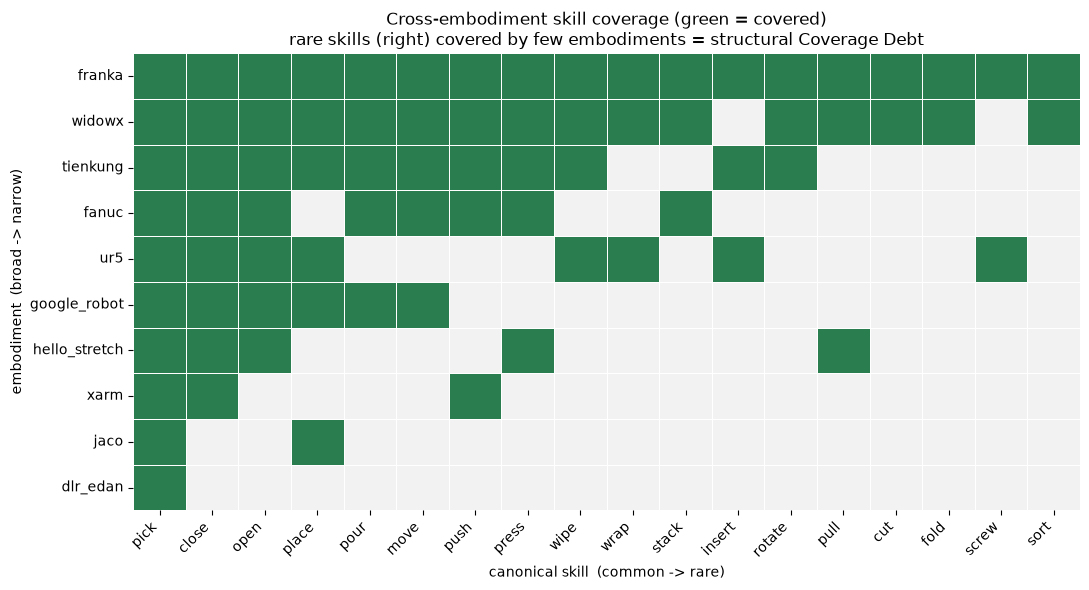

In [7]:
"""
Coverage Debt at Scale - Path A finalize
========================================
(1) normalize/merge embodiment names by robot family, separate sim vs real
(2) binary presence matrix + structural Coverage Debt index (simple + risk-weighted)
(3) embodiment x skill heatmap (paper main figure)

Reads outputs/embodiment_skill_matrix.csv (no network).
Env: Python 3.12, Windows (I:/ROBO). Needs matplotlib + seaborn.
"""

import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE = r"I:/ROBO"; OUT = os.path.join(BASE, "outputs")
raw = pd.read_csv(os.path.join(OUT, "embodiment_skill_matrix.csv"), index_col=0)
SKILLS = list(raw.columns)

# a-priori contact-risk weight per canonical skill (reported ALONGSIDE unweighted;
# see critique: unweighted is the assumption-free primary).
RISKW = {"insert": 3, "screw": 3, "cut": 3, "stack": 3, "pour": 3, "fold": 3, "press": 3,
         "push": 2, "pull": 2, "rotate": 2, "wipe": 2, "wrap": 2, "open": 2, "close": 2,
         "pick": 1, "place": 1, "move": 1, "sort": 1}


def normalize(emb):
    e = emb.lower()
    sim = ("sim" in e) or ("simulation" in e)
    if "franka" in e or "fr3" in e:
        fam = "franka"
    elif "tienkung" in e:
        fam = "tienkung"
    elif "agilex" in e:
        fam = "agilex"
    elif "widowx" in e:
        fam = "widowx"
    elif "google" in e:
        fam = "google_robot"
    elif "xarm" in e:
        fam = "xarm"
    elif "jaco" in e:
        fam = "jaco"
    elif "sawyer" in e:
        fam = "sawyer"
    elif "fanuc" in e:
        fam = "fanuc"
    elif "stretch" in e:
        fam = "hello_stretch"
    elif "edan" in e:
        fam = "dlr_edan"
    elif re.search(r"(^|_)ur", e):
        fam = "ur5"
    elif "simulation" in e:
        fam = "sim_generic"
    else:
        fam = e
    return f"{fam} [sim]" if sim else fam


raw["emb"] = [normalize(e) for e in raw.index]
counts = raw.groupby("emb")[SKILLS].sum()
binm = (counts > 0).astype(int)

real = binm.loc[[i for i in binm.index if "[sim]" not in i]]
simm = binm.loc[[i for i in binm.index if "[sim]" in i]]

# -------- structural coverage debt over REAL embodiments --------
n = len(real)
not_cov = 1 - real.sum(axis=0) / n
w = pd.Series(RISKW).reindex(SKILLS).fillna(1)
tbl = pd.DataFrame({
    "n_embod_covering": real.sum(axis=0).astype(int),
    "frac_not_covering": not_cov.round(3),
    "risk_weight": w.astype(int),
}).sort_values("frac_not_covering", ascending=False)
tbl["weighted_debt"] = (tbl.frac_not_covering * tbl.risk_weight).round(3)
tbl.to_csv(os.path.join(OUT, "structural_coverage_debt.csv"))

CD_simple = float(not_cov.mean())
CD_risk = float((not_cov * w).sum() / w.sum())

print(f"real embodiments ({n}): {list(real.index)}")
print(f"sim embodiments ({len(simm)}): {list(simm.index)}")
print("\n=== per-skill structural coverage debt (real embodiments) ===")
print(tbl.to_string())
print(f"\nStructural Coverage Debt (simple, unweighted)   = {CD_simple:.3f}")
print(f"Structural Coverage Debt (contact-risk-weighted) = {CD_risk:.3f}")

# per-embodiment coverage
cov = pd.DataFrame({"skills": real.sum(axis=1).astype(int),
                    "debt": (len(SKILLS) - real.sum(axis=1)).astype(int)}
                   ).sort_values("skills", ascending=False)
print("\n=== per-embodiment coverage (of", len(SKILLS), "skills) ===")
print(cov.to_string())

# -------- heatmap (paper main figure) --------
skill_order = real.sum(axis=0).sort_values(ascending=False).index
emb_order = real.sum(axis=1).sort_values(ascending=False).index
Hm = real.loc[emb_order, skill_order]
plt.figure(figsize=(11, 6))
sns.heatmap(Hm, cmap=sns.color_palette(["#f2f2f2", "#2a7d4f"]), cbar=False,
            linewidths=0.6, linecolor="white")
plt.title("Cross-embodiment skill coverage (green = covered)\n"
          "rare skills (right) covered by few embodiments = structural Coverage Debt")
plt.xlabel("canonical skill  (common -> rare)")
plt.ylabel("embodiment  (broad -> narrow)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "figure_embodiment_skill_heatmap.png"), dpi=160)
print("\nsaved -> structural_coverage_debt.csv + figure_embodiment_skill_heatmap.png")

Ontology kappa · PY

In [1]:
"""
Ontology validation via Cohen's kappa (critique C1/C3)
======================================================
AgiBot action segments carry BOTH a free-text action_text AND an authoritative
'skill' label. We map:
  rater A = our canonical mapping applied to action_text (free text)
  rater B = AgiBot's own skill label mapped to the same canonical set
and report Cohen's kappa. High agreement => our ontology is not subjective; it
aligns with an independent controlled vocabulary. Disagreements guide refinement.

Fully local (uses data/agibot_sample/task_info). Env: Python 3.12, Windows.
"""

import os
import re
import glob
import json
from collections import Counter

from sklearn.metrics import cohen_kappa_score

BASE = r"I:/ROBO"
AGI = os.path.join(BASE, "data/agibot_sample/task_info")
OUT = os.path.join(BASE, "outputs")

# our canonical ontology (verb -> skill) -- identical to the Path A pipeline
SKILL = {}
for verbs, sk in [
    (["pick", "grasp", "grab", "lift", "take", "get", "retrieve", "reach",
      "fetch", "gather", "collect", "grip"], "pick"),
    (["place", "put", "set", "deposit", "lay", "drop"], "place"),
    (["move", "transport", "carry", "bring", "deliver", "pass", "handover",
      "throw", "toss"], "move"),
    (["push"], "push"), (["pull", "drag"], "pull"),
    (["open"], "open"), (["close"], "close"),
    (["insert", "plug"], "insert"),
    (["pour", "fill", "water", "add", "scoop", "dip", "stir"], "pour"),
    (["fold", "unfold"], "fold"),
    (["wipe", "clean", "brush", "sweep", "scrub", "mop"], "wipe"),
    (["stack", "pile", "unstack"], "stack"),
    (["rotate", "turn", "flip", "twist", "upright", "slide"], "rotate"),
    (["press", "tap", "toggle", "switch"], "press"),
    (["cut", "slice", "peel"], "cut"),
    (["screw", "uncap", "fasten", "unscrew"], "screw"),
    (["sort", "classify", "arrange", "stow", "hang"], "sort"),
    (["wrap", "cover", "drape"], "wrap"),
]:
    for v in verbs:
        SKILL[v] = sk
STOP = {"the", "a", "an", "to", "then", "with", "and", "of", "on", "into", "onto",
        "left", "right", "up", "down", "your", "its", "no", "two", "dual", "single"}

# AgiBot authoritative label -> our canonical set
AGI2CANON = {
    "pick": "pick", "grasp": "pick", "lift": "pick", "hold": "pick",
    "place": "place", "drop": "place", "lower": "place", "hang": "place",
    "release": "place",
    "move": "move", "handover": "move",
    "push": "push", "pull": "pull", "pullapart": "pull",
    "open": "open", "close": "close", "insert": "insert",
    "pour": "pour", "dip": "pour",
    "fold": "fold", "unfold": "fold", "stretch": "fold",
    "wipe": "wipe", "brush": "wipe", "iron": "wipe",
    "stack": "stack",
    "press": "press", "pressbutton": "press", "tap": "press",
    "rotate": "rotate", "flip": "rotate", "shake": "rotate",
    "scan": "other", "sort": "sort",
}


def our_skill(text):
    for t in re.findall(r"[a-z]+", text.lower()):
        if t in STOP:
            continue
        if t in SKILL:
            return SKILL[t]
    return "other"


def agi_canon(label):
    return AGI2CANON.get(str(label).lower(), "other")


def main():
    A, Bv = [], []
    for f in glob.glob(os.path.join(AGI, "*.json")):
        for rec in json.load(open(f, encoding="utf-8")):
            for seg in (rec.get("label_info") or {}).get("action_config") or []:
                at, sk = seg.get("action_text"), seg.get("skill")
                if at and sk:
                    A.append(our_skill(at))
                    Bv.append(agi_canon(sk))

    n = len(A)
    agree = sum(1 for a, b in zip(A, Bv) if a == b) / n
    kappa = cohen_kappa_score(A, Bv)
    # kappa excluding segments either side mapped to 'other'
    pairs = [(a, b) for a, b in zip(A, Bv) if a != "other" and b != "other"]
    kappa_core = cohen_kappa_score([a for a, _ in pairs], [b for _, b in pairs])

    print(f"segments compared: {n}")
    print(f"raw agreement:            {agree:.3f}")
    print(f"Cohen's kappa (all):      {kappa:.3f}")
    print(f"Cohen's kappa (core, no 'other'): {kappa_core:.3f}   (on {len(pairs)} segments)")

    dis = Counter()
    for a, b in zip(A, Bv):
        if a != b:
            dis[(b, a)] += 1  # (agibot_label, our_label)
    print("\ntop disagreements  (AgiBot -> ours : count):")
    for (b, a), c in dis.most_common(12):
        print(f"   {b:8s} -> {a:8s} : {c}")


if __name__ == "__main__":
    main()

segments compared: 184883
raw agreement:            0.697
Cohen's kappa (all):      0.605
Cohen's kappa (core, no 'other'): 0.676   (on 166096 segments)

top disagreements  (AgiBot -> ours : count):
   fold     -> pick     : 16466
   place    -> other    : 7840
   fold     -> other    : 6534
   place    -> sort     : 4124
   wipe     -> press    : 3980
   place    -> move     : 2748
   pick     -> other    : 2024
   pick     -> place    : 1909
   pull     -> rotate   : 1844
   push     -> rotate   : 1844
   wipe     -> pick     : 1654
   pull     -> open     : 1479


Coverage per episode · PY

In [2]:
"""
Support-weighted coverage from per-episode metadata (critique C2)
================================================================
Moves coverage from 'unique task string exists' to 'at least K episodes
demonstrate this skill', using LeRobot meta/episodes. This prevents a single
stray task string from inflating coverage and yields a robustness check: does
the Structural Coverage Debt finding hold under a stricter presence definition?

Downloads ONLY per-subset episode metadata (no video). Env: Python 3.12, Windows.
"""

import os
import re
import json
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from huggingface_hub import HfApi, hf_hub_download

BASE = r"I:/ROBO"; OUT = os.path.join(BASE, "outputs")
META = os.path.join(BASE, "data/oxe_lerobot_epmeta"); os.makedirs(META, exist_ok=True)
api = HfApi()
LIMIT = 25
MIN_SUPPORT = 5  # episodes required for a skill to count as covered

SKILL = {}
for verbs, sk in [
    (["pick", "grasp", "grab", "lift", "take", "get", "retrieve", "reach",
      "fetch", "gather", "collect", "grip"], "pick"),
    (["place", "put", "set", "deposit", "lay", "drop"], "place"),
    (["move", "transport", "carry", "bring", "deliver", "pass", "handover",
      "throw", "toss"], "move"),
    (["push"], "push"), (["pull", "drag"], "pull"),
    (["open"], "open"), (["close"], "close"),
    (["insert", "plug"], "insert"),
    (["pour", "fill", "water", "add", "scoop", "dip", "stir"], "pour"),
    (["fold", "unfold"], "fold"),
    (["wipe", "clean", "brush", "sweep", "scrub", "mop"], "wipe"),
    (["stack", "pile", "unstack"], "stack"),
    (["rotate", "turn", "flip", "twist", "upright", "slide"], "rotate"),
    (["press", "tap", "toggle", "switch"], "press"),
    (["cut", "slice", "peel"], "cut"),
    (["screw", "uncap", "fasten", "unscrew"], "screw"),
    (["sort", "classify", "arrange", "stow", "hang"], "sort"),
    (["wrap", "cover", "drape"], "wrap"),
]:
    for v in verbs:
        SKILL[v] = sk
CANON = sorted(set(SKILL.values()))
STOP = {"the", "a", "an", "to", "then", "with", "and", "of", "on", "into", "onto",
        "left", "right", "up", "down", "your", "its", "no", "two", "dual", "single"}


def skill_of(text):
    for t in re.findall(r"[a-z]+", str(text).lower()):
        if t in STOP:
            continue
        if t in SKILL:
            return SKILL[t]
    return "other"


def normalize(emb):
    e = emb.lower()
    for key, fam in [("franka", "franka"), ("fr3", "franka"), ("tienkung", "tienkung"),
                     ("agilex", "agilex"), ("widowx", "widowx"), ("google", "google_robot"),
                     ("xarm", "xarm"), ("jaco", "jaco"), ("sawyer", "sawyer"),
                     ("fanuc", "fanuc"), ("stretch", "hello_stretch"), ("edan", "dlr_edan")]:
        if key in e:
            return fam
    if re.search(r"(^|_)ur", e):
        return "ur5"
    return e


def retry(fn, *a, **k):
    for i in range(5):
        try:
            return fn(*a, **k)
        except Exception:
            time.sleep(2 * (i + 1))
    return None


def episode_tasks(repo, files):
    """return list of task strings, one per episode (repeats allowed)."""
    cand = [f for f in files if f.startswith("meta/") and "episode" in f.lower()]
    if not cand:
        return []
    lp = retry(hf_hub_download, repo, repo_type="dataset", filename=cand[0],
               local_dir=os.path.join(META, repo.replace("/", "_")))
    if not lp:
        return []
    tasks = []
    if lp.endswith(".jsonl"):
        for line in open(lp, encoding="utf-8"):
            if line.strip():
                try:
                    j = json.loads(line)
                    t = j.get("tasks")
                    tasks.append(t[0] if isinstance(t, list) and t else (t or ""))
                except Exception:
                    pass
    elif lp.endswith(".parquet"):
        df = pd.read_parquet(lp)
        col = next((c for c in df.columns if "task" in c.lower()), None)
        if col:
            for v in df[col].tolist():
                tasks.append(v[0] if isinstance(v, (list, np.ndarray)) and len(v) else v)
    return [t for t in tasks if t]


def main():
    ds = retry(api.list_datasets, author="IPEC-COMMUNITY", limit=500) or []
    repos = [d.id for d in ds if "lerobot" in d.id.lower()][:LIMIT]
    ep_counts = defaultdict(Counter)  # embodiment -> skill -> episode count
    for repo in repos:
        files = retry(api.list_repo_files, repo, repo_type="dataset") or []
        robot = repo.split("/")[-1].replace("_lerobot", "")
        if "meta/info.json" in files:
            try:
                p = retry(hf_hub_download, repo, repo_type="dataset",
                          filename="meta/info.json",
                          local_dir=os.path.join(META, repo.replace("/", "_")))
                rt = json.load(open(p, encoding="utf-8")).get("robot_type")
                if rt and str(rt).lower() not in ("", "unknown", "none"):
                    robot = str(rt)
            except Exception:
                pass
        emb = normalize(robot)
        for t in episode_tasks(repo, files):
            s = skill_of(t)
            if s != "other":
                ep_counts[emb][s] += 1
        print(f"{repo.split('/')[-1][:34]:34s} emb={emb:14s} "
              f"episodes={sum(ep_counts[emb].values())}")

    embs = sorted(ep_counts)
    mat = pd.DataFrame(0, index=embs, columns=CANON)
    for e in embs:
        for s, c in ep_counts[e].items():
            mat.loc[e, s] = c
    mat.to_csv(os.path.join(OUT, "embodiment_skill_episodes.csv"))

    # robust presence: >= MIN_SUPPORT episodes
    binm = (mat >= MIN_SUPPORT).astype(int)
    n = len(binm)
    not_cov = 1 - binm.sum(axis=0) / n
    scd = float(not_cov.mean())
    print(f"\nrobust presence threshold: >= {MIN_SUPPORT} episodes")
    print(f"embodiments: {n}")
    print("\nper-skill breadth (episode-support based, long-tail first):")
    print(binm.sum(axis=0).sort_values().to_string())
    print(f"\nStructural Coverage Debt (support-weighted, K={MIN_SUPPORT}) = {scd:.3f}")
    print("compare to string-based SCD = 0.567")
    print("\nsaved -> embodiment_skill_episodes.csv")


if __name__ == "__main__":
    main()

c:\Users\PC369\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


bridge_orig_lerobot                emb=widowx         episodes=34691
fractal20220817_data_lerobot       emb=google_robot   episodes=83411


'Server disconnected without sending a response.' thrown while requesting GET https://huggingface.co/api/datasets/IPEC-COMMUNITY/droid_lerobot/tree/main?expand=false&recursive=true&limit=1000&cursor=ZXlKbWFXeGxYMjVoYldVaU9pSjJhV1JsYjNNdlkyaDFibXN0TURZd0wyOWljMlZ5ZG1GMGFXOXVMbWx0WVdkbGN5NWxlSFJsY21sdmNsOXBiV0ZuWlY4eFgyeGxablF2WlhCcGMyOWtaVjh3TmpBeU9USXViWEEwSWl3aWRISmxaVjl2YVdRaU9pSmtOV1EyTkROa01UQmhNekJtTnpGak4yRmhORFE1TUdGbE9UWTVaRFUzWmpBd05tTTNOVFF5SW4wPToyNzMwMDA%3D
Retrying in 1s [Retry 1/5].


droid_lerobot                      emb=franka         episodes=47052
nyu_franka_play_dataset_lerobot    emb=franka         episodes=47052
ucsd_kitchen_dataset_lerobot       emb=xarm           episodes=150
dlr_edan_shared_control_lerobot    emb=dlr_edan       episodes=48
nyu_door_opening_surprising_effect emb=hello_stretch  episodes=435
viola_lerobot                      emb=franka         episodes=47142
jaco_play_lerobot                  emb=jaco           episodes=976
roboturk_lerobot                   emb=sawyer         episodes=0


'peer closed connection without sending complete message body (incomplete chunked read)' thrown while requesting GET https://huggingface.co/api/datasets/IPEC-COMMUNITY/taco_play_lerobot/tree/main?expand=false&recursive=true&limit=1000&cursor=ZXlKbWFXeGxYMjVoYldVaU9pSjJhV1JsYjNNdlkyaDFibXN0TURBeEwyOWljMlZ5ZG1GMGFXOXVMbWx0WVdkbGN5NXlaMkpmWjNKcGNIQmxjaTlsY0dsemIyUmxYekF3TVRjek1pNXRjRFFpTENKMGNtVmxYMjlwWkNJNkltUTNaV0U1TVRVNE5EazBOR1ZsWm1Fek5tUmlZelpqTURsaVlqVXlPR1F4TTJaak56TTFaamtpZlE9PTo2MDAw
Retrying in 1s [Retry 1/5].


taco_play_lerobot                  emb=franka         episodes=50289
toto_lerobot                       emb=franka         episodes=51191
austin_sailor_dataset_lerobot      emb=franka         episodes=51281
austin_sirius_dataset_lerobot      emb=franka         episodes=51840
cmu_stretch_lerobot                emb=hello_stretch  episodes=570
iamlab_cmu_pickup_insert_lerobot   emb=franka         episodes=52471
furniture_bench_dataset_lerobot    emb=franka         episodes=52471
dobbe_lerobot                      emb=hello_stretch  episodes=5778
berkeley_cable_routing_lerobot     emb=franka         episodes=52471
austin_buds_dataset_lerobot        emb=franka         episodes=52521
cmu_play_fusion_lerobot            emb=franka         episodes=53097
berkeley_rpt_lerobot               emb=franka         episodes=53764
berkeley_mvp_lerobot               emb=xarm           episodes=630
berkeley_autolab_ur5_lerobot       emb=ur5            episodes=896
berkeley_fanuc_manipulation_lerobo emb=fa

Bonus causal · PY

=== per-task mean success vs skill coverage ===
             task skill  coverage  mean_success
       stack_cube stack         3        15.950
        move_near  move         5        42.200
     put_eggplant place         6        23.600
       put_carrot place         6         4.150
    put_in_drawer place         6         6.250
        put_spoon place         6         6.250
open_close_drawer  open         7        41.775
    pick_coke_can  pick        10        44.525

Spearman (per-task, n=8):  rho=0.293  p=0.481
Spearman (per policy-task, n=24): rho=0.272  p=0.198

(Underpowered: 'place' spans 5 tasks at one coverage value with success 0-43% -> coverage cannot explain within-skill variance.)

saved -> figure_coverage_vs_success.png


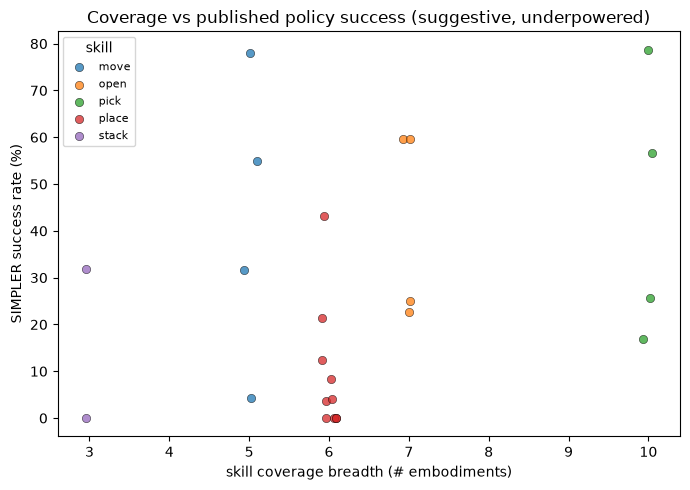

In [3]:
"""
Bonus: does structural coverage relate to policy success? (published rates)
==========================================================================
Correlates per-skill coverage breadth (our audit) with PUBLISHED SIMPLER
success rates. Honest caveat: SIMPLER's ~8 tasks collapse onto ~5 skills with
little coverage variance, so this is underpowered and reported as suggestive
evidence / future work, not a primary claim.

Published sources (transcribed):
  Google Robot (Visual Matching) - CronusVLA, arXiv:2506.19816, Table 8
  WidowX (Bridge)                - GEM, arXiv:2605.28548, Table 5
Coverage: outputs/structural_coverage_debt.csv (n_embod_covering per skill).
Env: Python 3.12, Windows (I:/ROBO).
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

BASE = r"I:/ROBO"; OUT = os.path.join(BASE, "outputs")

# (task, canonical_skill, {policy: success%})
DATA = [
    # Google Robot (CronusVLA Tbl 8)
    ("pick_coke_can", "pick", {"RT-1-X": 56.7, "RT-2-X": 78.7, "Octo": 17.0, "OpenVLA": 25.7}),
    ("move_near",     "move", {"RT-1-X": 31.7, "RT-2-X": 77.9, "Octo": 4.2,  "OpenVLA": 55.0}),
    ("open_close_drawer", "open", {"RT-1-X": 59.7, "RT-2-X": 25.0, "Octo": 22.7, "OpenVLA": 59.7}),
    ("put_in_drawer", "place", {"RT-1-X": 21.3, "RT-2-X": 3.7, "Octo": 0.0, "OpenVLA": 0.0}),
    # WidowX (GEM Tbl 5)
    ("put_carrot",   "place", {"Octo": 8.3,  "OpenVLA": 0.0}),
    ("put_eggplant", "place", {"Octo": 43.1, "OpenVLA": 4.1}),
    ("put_spoon",    "place", {"Octo": 12.5, "OpenVLA": 0.0}),
    ("stack_cube",   "stack", {"Octo": 31.9, "OpenVLA": 0.0}),
]


def main():
    cov = pd.read_csv(os.path.join(OUT, "structural_coverage_debt.csv"), index_col=0)
    breadth = cov["n_embod_covering"].to_dict()

    rows = []
    for task, skill, succ in DATA:
        b = breadth.get(skill, np.nan)
        for pol, s in succ.items():
            rows.append({"task": task, "skill": skill, "coverage": b,
                         "policy": pol, "success": s})
    df = pd.DataFrame(rows)

    # per-task mean success
    per_task = (df.groupby(["task", "skill", "coverage"])
                  .success.mean().reset_index().rename(columns={"success": "mean_success"}))
    print("=== per-task mean success vs skill coverage ===")
    print(per_task.sort_values("coverage").to_string(index=False))

    r1, p1 = spearmanr(per_task.coverage, per_task.mean_success)
    r2, p2 = spearmanr(df.coverage, df.success)
    print(f"\nSpearman (per-task, n={len(per_task)}):  rho={r1:.3f}  p={p1:.3f}")
    print(f"Spearman (per policy-task, n={len(df)}): rho={r2:.3f}  p={p2:.3f}")
    print("\n(Underpowered: 'place' spans 5 tasks at one coverage value with "
          "success 0-43% -> coverage cannot explain within-skill variance.)")

    # scatter
    plt.figure(figsize=(7, 5))
    skills = per_task.skill.unique()
    cmap = plt.cm.tab10
    for i, sk in enumerate(skills):
        d = df[df.skill == sk]
        plt.scatter(d.coverage + np.random.uniform(-0.1, 0.1, len(d)), d.success,
                    label=sk, color=cmap(i), alpha=0.75, edgecolor="k", linewidth=0.4)
    plt.xlabel("skill coverage breadth (# embodiments)")
    plt.ylabel("SIMPLER success rate (%)")
    plt.title("Coverage vs published policy success (suggestive, underpowered)")
    plt.legend(title="skill", fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, "figure_coverage_vs_success.png"), dpi=150)
    print("\nsaved -> figure_coverage_vs_success.png")


if __name__ == "__main__":
    main()

Paper figures · PY

saved -> figure2_rarefaction_ci.png
saved -> figure3_per_skill_debt.png


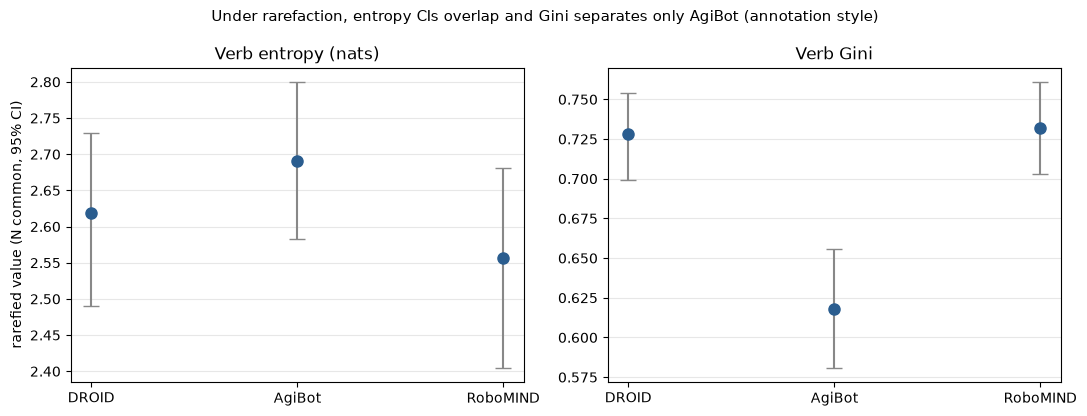

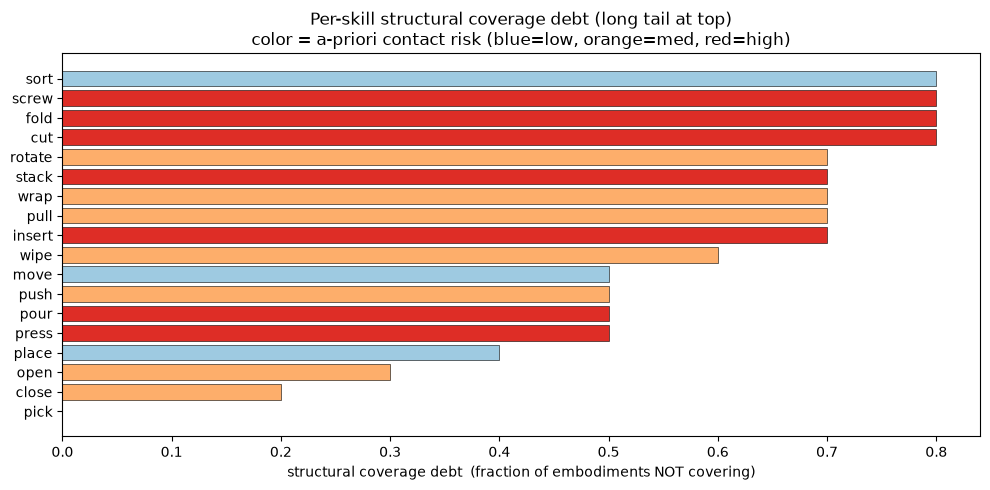

In [4]:
"""
Paper figures 2 and 3
=====================
Figure 2 (Motivation): rarefied entropy vs Gini with 95% CIs -> entropy CIs
  overlap while Gini separates only AgiBot (annotation style), showing
  language-diversity metrics do not robustly separate coverage.
Figure 3 (Main): per-skill structural coverage debt (long tail).

Reads outputs/backbone_rarefied_ci.csv and outputs/structural_coverage_debt.csv.
Env: Python 3.12, Windows (I:/ROBO).
"""

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = r"I:/ROBO"; OUT = os.path.join(BASE, "outputs")


def parse_ci(s):
    lo, hi = re.findall(r"[-\d.]+", str(s))[:2]
    return float(lo), float(hi)


def figure2():
    df = pd.read_csv(os.path.join(OUT, "backbone_rarefied_ci.csv"))
    ds = df["dataset"].tolist()
    x = np.arange(len(ds))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

    for ax, mean_col, ci_col, title in [
        (ax1, "entropy", "entropy_CI", "Verb entropy (nats)"),
        (ax2, "gini", "gini_CI", "Verb Gini")]:
        means = df[mean_col].values
        cis = [parse_ci(c) for c in df[ci_col]]
        lo = means - np.array([c[0] for c in cis])
        hi = np.array([c[1] for c in cis]) - means
        ax.errorbar(x, means, yerr=[lo, hi], fmt="o", capsize=6, ms=8,
                    color="#2a5d8f", ecolor="#888", lw=1.5)
        ax.set_xticks(x); ax.set_xticklabels(ds)
        ax.set_title(title)
        ax.grid(axis="y", alpha=0.3)
    ax1.set_ylabel("rarefied value (N common, 95% CI)")
    fig.suptitle("Under rarefaction, entropy CIs overlap and Gini separates only "
                 "AgiBot (annotation style)", fontsize=11)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT, "figure2_rarefaction_ci.png"), dpi=160)
    print("saved -> figure2_rarefaction_ci.png")


def figure3():
    t = pd.read_csv(os.path.join(OUT, "structural_coverage_debt.csv"), index_col=0)
    t = t.sort_values("frac_not_covering")
    colors = {1: "#9ecae1", 2: "#fdae6b", 3: "#de2d26"}
    bar_colors = [colors.get(int(w), "#ccc") for w in t["risk_weight"]]
    plt.figure(figsize=(10, 5))
    plt.barh(t.index, t["frac_not_covering"], color=bar_colors, edgecolor="k", linewidth=0.4)
    plt.xlabel("structural coverage debt  (fraction of embodiments NOT covering)")
    plt.title("Per-skill structural coverage debt (long tail at top)\n"
              "color = a-priori contact risk (blue=low, orange=med, red=high)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, "figure3_per_skill_debt.png"), dpi=160)
    print("saved -> figure3_per_skill_debt.png")


if __name__ == "__main__":
    figure2()
    figure3()

Finalize reviewer analyses · PY

In [2]:
# در همان حلقه‌ای که برای هر ردیف (embodiment, متنِ تسک) داری — قبل از نگاشت به skill:
import pandas as pd
rows = []                       # (embodiment, text) را همان‌طور که دیتاست‌ها را می‌پیمایی جمع کن
# OXE از task-table های LeRobot، RoboMIND از instruction csv، AgiBot از action_text
pd.DataFrame(rows, columns=["embodiment", "text"]).to_csv(
    r"I:/ROBO/outputs/embodiment_task_strings.csv", index=False)

In [5]:
# -*- coding: utf-8 -*-
"""
finalize_reviewer_analyses.py  —  closes reviewer items M2 and M3 in one run.
===========================================================================
Run:  python finalize_reviewer_analyses.py
Env:  Python 3.12, Windows, CPU-only. Needs pandas, numpy, matplotlib.

INPUT (one of):
  (A) I:/ROBO/outputs/task_strings.csv   with a text column, plus (ideally)
      'embodiment' and 'dataset' columns. One row per task-string occurrence.
  (B) per-dataset CSVs in I:/ROBO/outputs/   named  *_tasks.csv  (e.g.
      droid_tasks.csv, agibot_tasks.csv, robomind_tasks.csv, bridge_tasks.csv),
      each with a text column; the dataset name is taken from the filename.

The script AUTO-DETECTS the text/embodiment/dataset columns, so exact names
don't matter. If no usable input is found it prints how to make one and exits
cleanly (no crash).

OUTPUT:
  * M2: SCD(leading) vs SCD(most-specific) + delta-SCD + per-skill breadth deltas
  * M3: rarefied entropy & Gini 95% CIs for every dataset (incl. BridgeData V2)
        and a regenerated 4-dataset Fig 2 -> outputs/fig2_rarefaction_4ds.(png|pdf)
Send me the printed numbers + the new fig2 file and I insert them into the paper.
"""
import os, re, sys, glob, numpy as np, pandas as pd

BASE = r"I:/ROBO"; OUT = os.path.join(BASE, "outputs")
N_RARE, B_BOOT, SEED = 479, 500, 0            # rarefaction budget / bootstraps
rng = np.random.default_rng(SEED)

# ---- 18 canonical skills + verb lexicon (specific -> transport) -------------
SPECIFIC = ["fold","insert","screw","cut","stack","pour","wipe","wrap","sort",
            "press","rotate","pull","open","close","push"]
TRANSPORT = ["place","move","pick"]
ALL_SKILLS = ["pick","place","move","open","close","push","pull","rotate","fold",
              "wipe","wrap","insert","pour","press","stack","cut","screw","sort"]
VERB2SKILL = {
 "fold":"fold","insert":"insert","plug":"insert","screw":"screw","unscrew":"screw",
 "cut":"cut","slice":"cut","stack":"stack","pour":"pour","wipe":"wipe","clean":"wipe",
 "wrap":"wrap","sort":"sort","press":"press","push":"push","rotate":"rotate","turn":"rotate",
 "twist":"rotate","pull":"pull","open":"open","close":"close","shut":"close",
 "place":"place","put":"place","set":"place","insert_":"insert","move":"move","push_":"push",
 "pick":"pick","grasp":"pick","grab":"pick","lift":"pick","take":"pick","hold":"pick",
}

def tok(t): return re.findall(r"[a-z]+", str(t).lower())
def map_leading(t):
    for w in tok(t):
        if w in VERB2SKILL: return VERB2SKILL[w]
    return None
def map_specific(t):
    verbs = [VERB2SKILL[w] for w in tok(t) if w in VERB2SKILL]
    if not verbs: return None
    for s in SPECIFIC:
        if s in verbs: return s
    for s in TRANSPORT:
        if s in verbs: return s
    return verbs[0]
def leading_verb(t):                 # raw first recognizable token (for rarefaction)
    ws = tok(t)
    return ws[0] if ws else None

# ---- flexible input loading ------------------------------------------------
def _pick(cols, cands):
    for c in cols:
        if c.lower() in cands: return c
    return None
def load_rows():
    p = os.path.join(OUT, "task_strings.csv")
    if os.path.exists(p):
        df = pd.read_csv(p)
        tcol = _pick(df.columns, {"text","task","instruction","language_instruction","desc","description"})
        ecol = _pick(df.columns, {"embodiment","robot","robot_type","embod"})
        dcol = _pick(df.columns, {"dataset","source","corpus"})
        if tcol is None:  # fall back to the first object column
            objc = [c for c in df.columns if df[c].dtype == object]
            tcol = objc[0] if objc else None
        if tcol is None or len(df)==0: return None
        out = pd.DataFrame({"text": df[tcol].astype(str)})
        out["embodiment"] = df[ecol] if ecol else "unknown"
        out["dataset"]    = df[dcol] if dcol else "unknown"
        return out.dropna(subset=["text"])
    # per-dataset *_tasks.csv fallback
    files = glob.glob(os.path.join(OUT, "*_tasks.csv"))
    if files:
        frames=[]
        for f in files:
            name = os.path.basename(f).replace("_tasks.csv","").lower()
            df = pd.read_csv(f)
            tcol = _pick(df.columns, {"text","task","instruction","language_instruction","desc","description"}) \
                   or next((c for c in df.columns if df[c].dtype==object), None)
            ecol = _pick(df.columns, {"embodiment","robot","robot_type"})
            if tcol is None: continue
            g = pd.DataFrame({"text": df[tcol].astype(str)})
            g["embodiment"] = df[ecol] if ecol else name
            g["dataset"] = name
            frames.append(g)
        if frames: return pd.concat(frames, ignore_index=True).dropna(subset=["text"])
    return None

# ---- M2: leading vs most-specific SCD --------------------------------------
def grid_scd(df, mapper):
    d = df.copy(); d["skill"] = d["text"].map(mapper); d = d.dropna(subset=["skill"])
    if d["embodiment"].nunique()==0: return None, None
    cov = d.groupby("embodiment")["skill"].apply(set)
    E = list(cov.index)
    breadth = {s: sum(s in cov[e] for e in E) for s in ALL_SKILLS}
    scd = float(np.mean([1 - breadth[s]/len(E) for s in ALL_SKILLS]))
    return scd, breadth

def run_M2(df):
    print("="*64); print("M2  Leading-verb sensitivity (Structural Coverage Debt)")
    if df["embodiment"].nunique() <= 1:
        print("  ! need an 'embodiment' column with >1 value; skipping M2."); return
    scdL,bL = grid_scd(df, map_leading)
    scdS,bS = grid_scd(df, map_specific)
    print(f"  embodiments={df['embodiment'].nunique()}  rows={len(df)}")
    print(f"  SCD (leading-verb, as in paper) = {scdL:.3f}   (sanity: expect ~0.567)")
    print(f"  SCD (most-specific re-mapping)  = {scdS:.3f}")
    print(f"  delta-SCD = {scdS - scdL:+.3f}")
    print("  per-skill breadth change (specific - leading), tail first:")
    for s in ["cut","fold","screw","sort","insert","stack","pull","rotate","wrap"]:
        print(f"    {s:7s} {bL[s]:2d} -> {bS[s]:2d}  ({bS[s]-bL[s]:+d})")
    ordL=[s for s in sorted(ALL_SKILLS,key=lambda x:bL[x])]
    ordS=[s for s in sorted(ALL_SKILLS,key=lambda x:bS[x])]
    print(f"  tail(6) leading : {ordL[:6]}")
    print(f"  tail(6) specific: {ordS[:6]}")
    print(f"  -> tail-set preserved: {set(ordL[:6])==set(ordS[:6])}")

# ---- M3: 4-dataset rarefaction ---------------------------------------------
def entropy(counts):
    p = counts/counts.sum(); p=p[p>0]; return float(-(p*np.log(p)).sum())
def gini(counts):
    x=np.sort(counts.astype(float)); n=len(x); s=x.sum()
    if s==0 or n==0: return 0.0
    return float((2*np.arange(1,n+1)-n-1).dot(x)/(n*s))
def rarefy_ci(verbs):
    verbs=[v for v in verbs if v]; arr=np.array(verbs)
    if len(arr)<N_RARE:  # sample WITH replacement to the common budget
        pass
    ents=[]; gs=[]
    for _ in range(B_BOOT):
        samp = rng.choice(arr, size=N_RARE, replace=True)
        _,c = np.unique(samp, return_counts=True)
        ents.append(entropy(c)); gs.append(gini(c))
    q=lambda a:(float(np.percentile(a,2.5)),float(np.median(a)),float(np.percentile(a,97.5)))
    return q(ents), q(gs), len(np.unique(arr))

def run_M3(df):
    print("="*64); print("M3  Rarefied first-verb statistics (incl. BridgeData V2)")
    if df["dataset"].nunique() <= 1:
        print("  ! need a 'dataset' column (droid/agibot/robomind/bridge); skipping M3."); return
    order=["droid","agibot","robomind","bridge"]
    dss=[d for d in order if d in set(df["dataset"].str.lower())]
    dss+=[d for d in df["dataset"].str.lower().unique() if d not in dss]
    res={}
    for d in dss:
        sub=df[df["dataset"].str.lower()==d]
        verbs=sub["text"].map(leading_verb).tolist()
        (eL,eM,eH),(gL,gM,gH),nv=rarefy_ci(verbs)
        res[d]=dict(ent=(eL,eM,eH),gini=(gL,gM,gH),nverb=nv,n=len(sub))
        print(f"  {d:9s} n={len(sub):6d} verbs={nv:4d} | "
              f"entropy 95%CI [{eL:.3f},{eH:.3f}] | Gini 95%CI [{gL:.3f},{gH:.3f}]")
    try:
        import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
        plt.rcParams.update({"font.family":"serif","font.size":9})
        labels=[d.upper() for d in dss]; x=np.arange(len(dss))
        fig,ax=plt.subplots(1,2,figsize=(6.6,2.6))
        for j,key in enumerate(["ent","gini"]):
            lo=[res[d][key][0] for d in dss]; mid=[res[d][key][1] for d in dss]; hi=[res[d][key][2] for d in dss]
            err=[np.array(mid)-np.array(lo),np.array(hi)-np.array(mid)]
            ax[j].errorbar(x,mid,yerr=err,fmt="o",color="#1f4e79",capsize=3)
            ax[j].set_xticks(x); ax[j].set_xticklabels(labels,rotation=0)
            ax[j].set_title("Verb entropy (nats)" if key=="ent" else "Verb Gini")
            ax[j].grid(axis="y",ls=":",alpha=.5)
        ax[0].set_ylabel("rarefied value (95% CI)")
        fig.tight_layout()
        fig.savefig(os.path.join(OUT,"fig2_rarefaction_4ds.png"),dpi=300,bbox_inches="tight")
        fig.savefig(os.path.join(OUT,"fig2_rarefaction_4ds.pdf"),bbox_inches="tight")
        print(f"  saved -> {os.path.join(OUT,'fig2_rarefaction_4ds.png / .pdf')}")
    except Exception as e:
        print("  (figure skipped:",e,")")

def main():
    os.makedirs(OUT, exist_ok=True)
    df = load_rows()
    if df is None or len(df)==0:
        print("No usable input found.\n"
              "Make I:/ROBO/outputs/task_strings.csv (columns: dataset,embodiment,text)\n"
              "in the SAME notebook where you built the matrix, e.g.:\n"
              '   out = your_df[["dataset","embodiment","text"]].dropna()\n'
              '   assert len(out)>0\n'
              '   out.to_csv(r"I:/ROBO/outputs/task_strings.csv", index=False, encoding="utf-8")\n'
              "or drop per-dataset *_tasks.csv files in outputs/. Then re-run this script.")
        return
    print(f"loaded {len(df)} rows | datasets={sorted(df['dataset'].str.lower().unique())} "
          f"| embodiments={df['embodiment'].nunique()}")
    run_M2(df); run_M3(df)
    print("="*64); print("Done. Send me the printed numbers + fig2_rarefaction_4ds.png.")

if __name__ == "__main__":
    main()

No usable input found.
Make I:/ROBO/outputs/task_strings.csv (columns: dataset,embodiment,text)
in the SAME notebook where you built the matrix, e.g.:
   out = your_df[["dataset","embodiment","text"]].dropna()
   assert len(out)>0
   out.to_csv(r"I:/ROBO/outputs/task_strings.csv", index=False, encoding="utf-8")
or drop per-dataset *_tasks.csv files in outputs/. Then re-run this script.



Dump task strings · PY

In [6]:
# =====================================================================
# PASTE THIS INTO A CELL IN THE SAME NOTEBOOK that built your matrix,
# and run it. It scans every DataFrame currently in memory, finds the
# one(s) holding raw task text + embodiment, and saves task_strings.csv.
# (Run your data-loading / matrix-building cells FIRST so the DataFrames
#  are alive in memory.)
# =====================================================================
import pandas as pd

def dump_task_strings(ns=None, out_path=r"I:/ROBO/outputs/task_strings.csv"):
    ns = ns if ns is not None else globals()
    TXT = {"text","task","instruction","instructions","language_instruction",
           "lang","language","description","desc","task_text","task_string","caption"}
    EMB = {"embodiment","robot","robot_type","embod","robot_name","platform"}
    DS  = {"dataset","source","corpus","dataset_name","ds"}
    frames, listing = [], []
    for name, obj in list(ns.items()):
        if name.startswith("_") or not isinstance(obj, pd.DataFrame) or len(obj) == 0:
            continue
        cl = {c.lower(): c for c in obj.columns}
        t = next((cl[c] for c in TXT if c in cl), None)
        e = next((cl[c] for c in EMB if c in cl), None)
        d = next((cl[c] for c in DS  if c in cl), None)
        if t:
            listing.append((name, len(obj), list(obj.columns), bool(e)))
        if t and e:
            g = pd.DataFrame({"embodiment": obj[e].astype(str),
                              "text": obj[t].astype(str)})
            g["dataset"] = obj[d].astype(str) if d else \
                           name.replace("_df", "").replace("_tasks", "").replace("df_", "")
            frames.append(g)
    if not frames:
        print("!! No DataFrame had BOTH a text column and an embodiment/robot column.")
        print("   DataFrames that DO have a text column (tell me which is the full task table,")
        print("   or re-run the cell that builds it so it's in memory):")
        for n, L, cols, he in listing:
            print(f"     {n}: {L} rows, has_embodiment={he}, cols={cols}")
        if not listing:
            print("   (none found — re-run your dataset-loading cells first, then this snippet)")
        return None
    out = pd.concat(frames, ignore_index=True).dropna()
    out = out[out["text"].str.strip().astype(bool)]
    out.to_csv(out_path, index=False, encoding="utf-8")
    print(f"OK: saved {len(out)} rows -> {out_path}")
    print("   embodiments:", sorted(out["embodiment"].unique())[:15])
    print("   datasets   :", sorted(out["dataset"].str.lower().unique())[:15])
    print("   -> now run:  python finalize_reviewer_analyses.py")
    return out

dump_task_strings()

!! No DataFrame had BOTH a text column and an embodiment/robot column.
   DataFrames that DO have a text column (tell me which is the full task table,
   or re-run the cell that builds it so it's in memory):
   (none found — re-run your dataset-loading cells first, then this snippet)


Close out m2 m3 · PY

In [7]:
# -*- coding: utf-8 -*-
"""
close_out_M2_M3.py  —  reproduces YOUR pipeline's reading (cells 34 & 36),
keeps the raw task text this time, and closes reviewer items M2 and M3.

It re-reads from the SAME sources your notebook uses, so you do NOT need any
in-memory DataFrame. Run it like your other cells (needs a valid HF login).

  python close_out_M2_M3.py

Outputs (to I:/ROBO/outputs/):
  * task_strings.csv               (dataset, embodiment, text)  [byproduct]
  * prints  M2:  SCD(leading) vs SCD(most-specific) + delta-SCD + tail check
  * prints  M3:  rarefied entropy & Gini 95% CIs for DROID/AgiBot/RoboMIND/Bridge
  * fig2_rarefaction_4ds.png / .pdf   (4-dataset Figure 2)

Send me the printed block + fig2_rarefaction_4ds.png and I paste the numbers in.
Env: Python 3.12, Windows (I:/ROBO), CPU-only.
"""
import os, re, json, glob, time
from collections import Counter
import numpy as np, pandas as pd

BASE = r"I:/ROBO"; OUT = os.path.join(BASE, "outputs"); os.makedirs(OUT, exist_ok=True)
META = os.path.join(BASE, "data/oxe_lerobot_meta"); os.makedirs(META, exist_ok=True)
N_RARE, B_BOOT = 479, 500
rng = np.random.default_rng(0)

# ---- canonical ontology + stopwords : IDENTICAL to cells 34/36 --------------
SKILL = {}
for verbs, sk in [
    (["pick","grasp","grab","lift","take","get","retrieve","reach","fetch","gather","collect","grip"],"pick"),
    (["place","put","set","deposit","lay","drop"],"place"),
    (["move","transport","carry","bring","deliver","pass","handover","throw","toss"],"move"),
    (["push"],"push"), (["pull","drag"],"pull"), (["open"],"open"), (["close"],"close"),
    (["insert","plug"],"insert"),
    (["pour","fill","water","add","scoop","dip","stir"],"pour"),
    (["fold","unfold"],"fold"),
    (["wipe","clean","brush","sweep","scrub","mop"],"wipe"),
    (["stack","pile","unstack"],"stack"),
    (["rotate","turn","flip","twist","upright","slide"],"rotate"),
    (["press","tap","toggle","switch"],"press"),
    (["cut","slice","peel"],"cut"),
    (["screw","uncap","fasten","unscrew"],"screw"),
    (["sort","classify","arrange","stow","hang"],"sort"),
    (["wrap","cover","drape"],"wrap"),
]:
    for v in verbs: SKILL[v] = sk
CANON = sorted(set(SKILL.values()))
STOP = {"the","a","an","to","then","with","and","of","on","into","onto","left","right",
        "up","down","your","its","no","two","dual","single"}
# specificity order for the M2 re-mapping (contact-rich/precise first, transport last)
SPEC_RANK = {s:i for i,s in enumerate(
    ["insert","screw","cut","fold","stack","pour","wipe","wrap","sort",
     "rotate","press","pull","push","open","close","move","place","pick"])}

def skill_leading(text):                     # == your skill_of(): first KNOWN verb
    for t in re.findall(r"[a-z]+", str(text).lower()):
        if t in STOP: continue
        if t in SKILL: return SKILL[t]
    return "other"

def skill_specific(text):                    # most-specific skill present in the string
    found = []
    for t in re.findall(r"[a-z]+", str(text).lower()):
        if t in STOP: continue
        if t in SKILL: found.append(SKILL[t])
    if not found: return "other"
    return min(found, key=lambda s: SPEC_RANK.get(s, 99))

def normalize(emb):                          # == cell 36 normalize()
    e = str(emb).lower(); sim = ("sim" in e) or ("simulation" in e)
    if "franka" in e or "fr3" in e: fam="franka"
    elif "tienkung" in e: fam="tienkung"
    elif "agilex" in e: fam="agilex"
    elif "widowx" in e: fam="widowx"
    elif "google" in e: fam="google_robot"
    elif "xarm" in e: fam="xarm"
    elif "jaco" in e: fam="jaco"
    elif "sawyer" in e: fam="sawyer"
    elif "fanuc" in e: fam="fanuc"
    elif "stretch" in e: fam="hello_stretch"
    elif "edan" in e: fam="dlr_edan"
    elif re.search(r"(^|_)ur", e): fam="ur5"
    elif "simulation" in e: fam="sim_generic"
    else: fam=e
    return f"{fam} [sim]" if sim else fam

# ---- rarefaction verb extraction : IDENTICAL to cell 32 ---------------------
TIERLESS_STOP = {"the","a","an","to","then","with","and","of","on","into","onto",
                 "left","right","up","down","your","its","no"}
def first_verb(s):
    toks=[t for t in re.findall(r"[a-z]+", str(s).lower()) if t not in TIERLESS_STOP]
    return toks[0] if toks else None

# =========================== SOURCE READERS (mirror cell 34) =================
def list_retry(fn,*a,tries=5,**k):
    for i in range(tries):
        try: return fn(*a,**k)
        except Exception: time.sleep(2*(i+1))
    return None

def read_sources():
    """Returns rows [{'dataset','embodiment','text'}] AND a dict of per-dataset
       verb streams for rarefaction. Mirrors your cell-34 readers but keeps text."""
    from huggingface_hub import HfApi, hf_hub_download
    api = HfApi()
    rows=[]; bridge_texts=[]
    # ---- OXE (LeRobot mirrors) ----
    ds = list_retry(api.list_datasets, author="IPEC-COMMUNITY", limit=500) or []
    repos = [d.id for d in ds if "lerobot" in d.id.lower()][:25]
    for repo in repos:
        files = list_retry(api.list_repo_files, repo, repo_type="dataset") or []
        robot = repo.split("/")[-1].replace("_lerobot","")
        if "meta/info.json" in files:
            try:
                p=hf_hub_download(repo,repo_type="dataset",filename="meta/info.json",
                                  local_dir=os.path.join(META,repo.replace("/","_")))
                rt=json.load(open(p,encoding="utf-8")).get("robot_type")
                if rt and str(rt).lower() not in ("","unknown","none"): robot=str(rt)
            except Exception: pass
        tcand=[f for f in files if f.startswith("meta/") and "task" in f.lower()]
        if not tcand: continue
        try:
            tp=hf_hub_download(repo,repo_type="dataset",filename=tcand[0],
                               local_dir=os.path.join(META,repo.replace("/","_")))
        except Exception: continue
        tasks=[]
        if tp.endswith(".jsonl"):
            for line in open(tp,encoding="utf-8"):
                if line.strip():
                    try: tasks.append(json.loads(line).get("task",""))
                    except Exception: pass
        elif tp.endswith(".parquet"):
            df=pd.read_parquet(tp); col=next((c for c in df.columns if "task" in c.lower()),df.columns[0])
            tasks=df[col].dropna().astype(str).tolist()
        is_bridge = "bridge" in repo.lower()
        for t in tasks:
            rows.append({"dataset":"bridge" if is_bridge else "oxe",
                         "embodiment":robot,"text":t})
            if is_bridge: bridge_texts.append(t)
        print(f"OXE {repo.split('/')[-1][:30]:30s} robot={str(robot)[:16]:16s} tasks={len(tasks)}"
              + ("  <-- BRIDGE" if is_bridge else ""))
    # ---- RoboMIND (path listing) ----
    files=list_retry(api.list_repo_files,"x-humanoid-robomind/RoboMIND",repo_type="dataset") or []
    seen=set()
    for f in files:
        if not f.startswith("benchmark"): continue
        p=f.split("/")
        if len(p)<3: continue
        emb=p[1]; task=p[2].split(".tar")[0]
        if (emb,task) in seen: continue
        seen.add((emb,task)); rows.append({"dataset":"robomind","embodiment":emb,"text":task})
    print(f"RoboMIND rows: {sum(1 for r in rows if r['dataset']=='robomind')}")
    return rows, bridge_texts

# ---- local rarefaction streams (mirror cell 32) ----
def droid_verbs():
    p=f"{BASE}/data/droid_sample/droid_language_annotations.json"
    if not os.path.exists(p): return []
    ann=json.load(open(p,encoding="utf-8"))
    texts=[s for v in ann.values() for s in (v.values() if isinstance(v,dict) else [v]) if isinstance(s,str)]
    return [first_verb(s) for s in texts if first_verb(s)]
def agibot_verbs():
    out=[]
    for f in glob.glob(f"{BASE}/data/agibot_sample/task_info/*.json"):
        try: recs=json.load(open(f,encoding="utf-8"))
        except Exception: continue
        for rec in (recs if isinstance(recs,list) else [recs]):
            for seg in (rec.get("label_info") or {}).get("action_config") or []:
                if seg.get("action_text"):
                    v=first_verb(seg["action_text"])
                    if v: out.append(v)
    return out
def robomind_verbs():
    p=f"{BASE}/data/robomind_meta/static/RoboMIND_v1_2_instr.csv"
    if not os.path.exists(p): return []
    rm=pd.read_csv(p); col="instruction" if "instruction" in rm.columns else rm.columns[-1]
    return [first_verb(s) for s in rm[col].dropna().astype(str) if first_verb(s)]

# =============================== M2 =========================================
def run_M2(rows):
    df=pd.DataFrame(rows); df["fam"]=df["embodiment"].map(normalize)
    df=df[~df["fam"].str.contains(r"\[sim\]")]                 # REAL embodiments only
    def scd(mapper):
        d=df.copy(); d["skill"]=d["text"].map(mapper); d=d[d["skill"]!="other"]
        cov=d.groupby("fam")["skill"].apply(set); E=list(cov.index)
        breadth={s:sum(s in cov[e] for e in E) for s in CANON}
        return float(np.mean([1-breadth[s]/len(E) for s in CANON])), breadth, len(E)
    sL,bL,nE=scd(skill_leading); sS,bS,_=scd(skill_specific)
    print("="*66); print("M2  Leading-verb sensitivity  (real embodiments =",nE,")")
    print(f"  SCD (leading, as in paper) = {sL:.3f}   (sanity: expect ~0.567)")
    print(f"  SCD (most-specific)        = {sS:.3f}")
    print(f"  delta-SCD                  = {sS-sL:+.3f}")
    print("  per-skill breadth change (specific - leading), tail first:")
    for s in ["cut","fold","screw","sort","insert","stack","pull","rotate","wrap"]:
        print(f"    {s:7s} {bL[s]:2d} -> {bS[s]:2d}  ({bS[s]-bL[s]:+d})")
    tL=sorted(CANON,key=lambda x:bL[x])[:6]; tS=sorted(CANON,key=lambda x:bS[x])[:6]
    print(f"  tail(6) leading : {tL}")
    print(f"  tail(6) specific: {tS}")
    print(f"  -> tail-set preserved: {set(tL)==set(tS)}")

# =============================== M3 =========================================
def entropy(c): p=c/c.sum(); p=p[p>0]; return float(-(p*np.log(p)).sum())
def gini(c):
    x=np.sort(c.astype(float)); n=len(x); s=x.sum()
    return 0.0 if s==0 else float((n+1-2*np.sum(np.cumsum(x))/s)/n)
def rarefy(verbs):
    a=np.array([v for v in verbs if v])
    if len(a)==0: return None
    E=[]; G=[]
    for _ in range(B_BOOT):
        s=rng.choice(a,size=N_RARE,replace=True); _,c=np.unique(s,return_counts=True)
        E.append(entropy(c)); G.append(gini(c))
    q=lambda z:(float(np.percentile(z,2.5)),float(np.median(z)),float(np.percentile(z,97.5)))
    return q(E),q(G),len(np.unique(a))
def run_M3(bridge_texts):
    streams={"DROID":droid_verbs(),"AgiBot":agibot_verbs(),
             "RoboMIND":robomind_verbs(),
             "Bridge":[first_verb(t) for t in bridge_texts if first_verb(t)]}
    print("="*66); print("M3  Rarefied first-verb statistics (incl. BridgeData V2)")
    res={}
    for name,vb in streams.items():
        r=rarefy(vb)
        if r is None: print(f"  {name:9s}  (no data found — check local path)"); continue
        (eL,eM,eH),(gL,gM,gH),nv=r; res[name]=(eM,eL,eH,gM,gL,gH)
        print(f"  {name:9s} verbs={nv:4d} | entropy 95%CI [{eL:.3f},{eH:.3f}] | "
              f"Gini 95%CI [{gL:.3f},{gH:.3f}]")
    if res:
        import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
        plt.rcParams.update({"font.family":"serif","font.size":9})
        names=list(res); x=np.arange(len(names))
        fig,ax=plt.subplots(1,2,figsize=(6.6,2.6))
        for j,(mi,lo,hi) in enumerate([(0,1,2),(3,4,5)]):
            m=[res[n][mi] for n in names]; l=[res[n][lo] for n in names]; h=[res[n][hi] for n in names]
            ax[j].errorbar(x,m,yerr=[np.array(m)-l,np.array(h)-m],fmt="o",color="#1f4e79",capsize=3)
            ax[j].set_xticks(x); ax[j].set_xticklabels(names); ax[j].grid(axis="y",ls=":",alpha=.5)
            ax[j].set_title("Verb entropy (nats)" if j==0 else "Verb Gini")
        ax[0].set_ylabel("rarefied value (95% CI)"); fig.tight_layout()
        fig.savefig(os.path.join(OUT,"fig2_rarefaction_4ds.png"),dpi=300,bbox_inches="tight")
        fig.savefig(os.path.join(OUT,"fig2_rarefaction_4ds.pdf"),bbox_inches="tight")
        print("  saved -> fig2_rarefaction_4ds.png / .pdf")

def main():
    rows, bridge_texts = read_sources()
    pd.DataFrame(rows).to_csv(os.path.join(OUT,"task_strings.csv"),index=False,encoding="utf-8")
    print(f"saved task_strings.csv ({len(rows)} rows)")
    run_M2(rows); run_M3(bridge_texts)
    print("="*66); print("Done. Send me the M2/M3 block + fig2_rarefaction_4ds.png.")

if __name__ == "__main__":
    main()

c:\Users\PC369\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OXE bridge_orig_lerobot            robot=widowx           tasks=19974  <-- BRIDGE
OXE fractal20220817_data_lerobot   robot=google_robot     tasks=599
OXE nyu_franka_play_dataset_lerobo robot=franka           tasks=1
OXE ucsd_kitchen_dataset_lerobot   robot=xarm             tasks=8
OXE dlr_edan_shared_control_lerobo robot=dlr_edan         tasks=10
OXE nyu_door_opening_surprising_ef robot=hello_stretch    tasks=1
OXE viola_lerobot                  robot=franka           tasks=3
OXE jaco_play_lerobot              robot=jaco_2           tasks=88
OXE roboturk_lerobot               robot=sawyer           tasks=3
OXE taco_play_lerobot              robot=franka           tasks=403
OXE toto_lerobot                   robot=franka           tasks=1
OXE austin_sailor_dataset_lerobot  robot=franka           tasks=4
OXE austin_sirius_dataset_lerobot  robot=franka           tasks=2
OXE cmu_stretch_lerobot            robot=hello_stretch    tasks=5
OXE iamlab_cmu_pickup_insert_lerob robot=franka       